# 15. Real Animals: Results

1. Cohort overview: assignment strip + consensus
2. Parameter distributions across cohort
3. GS vs SBI consistency
4. Example animal deep-dives
5. Dynamic SBI trajectories
6. Drill-down (pick any animal)

In [1]:
%matplotlib inline
from shared_setup import *
import pickle, torch
from pathlib import Path
from collections import Counter
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from plotting.animal_report import (
    plot_animal_summary, plot_cv_results,
    plot_model_fits, plot_sbi_diagnostics,
)
from behav_utils.plotting.styles import COLOURS

BE_COL, SC_COL = COLOURS['BE'], COLOURS['SC']

In [2]:
RESULTS_DIR = Path('../results')
SNPE_DIR = RESULTS_DIR / 'snpe'
FIT_TARGETS = ['update_matrix', 'conditional_psych']
FT_LABEL = {'update_matrix': 'UM', 'conditional_psych': 'CP'}

# ── Animals to show in detail (change as needed) ──────────────────────────
EXAMPLE_ANIMALS = ['SS05', 'SS07']

experiment, info = load_data()

# SNPE networks
snpe = {}
for model in ['be', 'sc']:
    p = SNPE_DIR / f'uniform_{model}.pkl'
    if p.exists():
        with open(p, 'rb') as f: snpe[model] = pickle.load(f)
        print(f'SNPE {model}: {snpe[model]["param_names"]}')

Loaded snapshot: 22 animals, 885 sessions (exported 2026-04-25)
SNPE be: ['sigma_percep', 'A_repulsion', 'eta_learning', 'eta_relax']
SNPE sc: ['sigma_percep', 'A_repulsion', 'gamma', 'sigma_update']


## Load All Assignments

In [3]:
from scipy.stats import wilcoxon

def load_all_assignments(results_dir, experiment):
    """
    Load GS + SBI assignments for all animals.
    Returns DataFrame with columns: id, GS-UM, GS-CP, SBI-UM, SBI-CP,
    plus p-values and mean errors.
    """
    cv_dir = results_dir / 'cv'
    sbi_dir = results_dir / 'sbi_static' / 'comparisons'

    # Collect all animal IDs
    all_ids = set()
    for ft in FIT_TARGETS:
        for p in (cv_dir / f'uniform_{ft}').glob('cv_*_BE.pkl'):
            all_ids.add(p.stem.replace('cv_', '').replace('_BE', ''))
        for p in (sbi_dir / f'uniform_{ft}').glob('animal_*.pkl'):
            all_ids.add(p.stem.replace('animal_', ''))
    # Also include animals from experiment
    all_ids |= set(experiment.animals.keys())

    rows = []
    for aid in sorted(all_ids):
        row = {'id': aid}

        for ft in FIT_TARGETS:
            ft_short = FT_LABEL[ft]

            # GS
            be_path = cv_dir / f'uniform_{ft}' / f'cv_{aid}_BE.pkl'
            sc_path = cv_dir / f'uniform_{ft}' / f'cv_{aid}_SC.pkl'
            if be_path.exists() and sc_path.exists():
                with open(be_path, 'rb') as f: be_data = pickle.load(f)
                with open(sc_path, 'rb') as f: sc_data = pickle.load(f)
                be_e = [r['avg_test_error'] for r in be_data['results']
                        if not np.isnan(r.get('avg_test_error', np.nan))]
                sc_e = [r['avg_test_error'] for r in sc_data['results']
                        if not np.isnan(r.get('avg_test_error', np.nan))]
                if be_e and sc_e:
                    be_m, sc_m = np.mean(be_e), np.mean(sc_e)
                    lower = 'BE' if be_m < sc_m else 'SC'
                    n = min(len(be_e), len(sc_e))
                    try:
                        _, p_val = wilcoxon(be_e[:n], sc_e[:n])
                    except Exception:
                        p_val = np.nan
                    row[f'GS-{ft_short}'] = lower
                    row[f'GS-{ft_short}_p'] = p_val
                    row[f'GS-{ft_short}_be'] = be_m
                    row[f'GS-{ft_short}_sc'] = sc_m

            # SBI
            sbi_path = sbi_dir / f'uniform_{ft}' / f'animal_{aid}.pkl'
            if sbi_path.exists():
                with open(sbi_path, 'rb') as f: comp = pickle.load(f)
                winner = comp.get('winner')
                p_val = comp.get('p', np.nan)
                if winner in ('BE', 'SC'):
                    row[f'SBI-{ft_short}'] = winner
                elif winner:
                    row[f'SBI-{ft_short}'] = winner  # Inconclusive etc
                row[f'SBI-{ft_short}_p'] = p_val
                row[f'SBI-{ft_short}_be'] = comp.get('be_mean')
                row[f'SBI-{ft_short}_sc'] = comp.get('sc_mean')

        rows.append(row)

    df = pd.DataFrame(rows)

    # Compute consensus
    method_cols = ['GS-UM', 'GS-CP', 'SBI-UM', 'SBI-CP']
    consensuses = []
    for _, row in df.iterrows():
        # Only count significant assignments
        votes = []
        for mc in method_cols:
            val = row.get(mc)
            p = row.get(f'{mc}_p', np.nan)
            if val in ('BE', 'SC') and (pd.notna(p) and p < 0.05):
                votes.append(val)
        if votes:
            counts = Counter(votes)
            top = counts.most_common(1)[0]
            if top[1] > len(votes) / 2:
                consensuses.append(top[0])
            else:
                consensuses.append('Split')
        else:
            consensuses.append('Unclear')
    df['Consensus'] = consensuses

    return df


assign_df = load_all_assignments(RESULTS_DIR, experiment)
print(f'{len(assign_df)} animals total')
print(f'\nConsensus summary:')
print(assign_df['Consensus'].value_counts().to_string())

22 animals total

Consensus summary:
Consensus
BE         11
Unclear     9
SC          2


---
## 1. Assignment Strip

All animals × all methods. Solid colour = significant (p < 0.05).
Faded = direction but not significant. Last column = consensus.

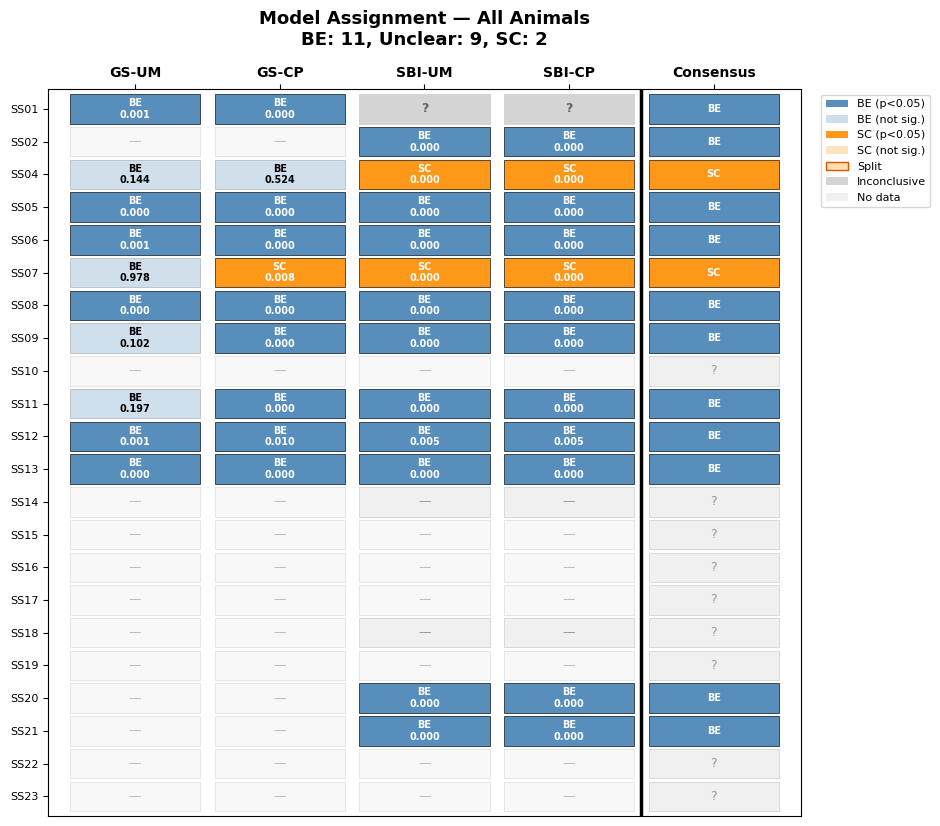

  id GS-UM GS-CP            SBI-UM            SBI-CP Consensus
SS01    BE    BE      Inconclusive      Inconclusive        BE
SS02   NaN   NaN                BE                BE        BE
SS04    BE    BE                SC                SC        SC
SS05    BE    BE                BE                BE        BE
SS06    BE    BE                BE                BE        BE
SS07    BE    SC                SC                SC        SC
SS08    BE    BE                BE                BE        BE
SS09    BE    BE                BE                BE        BE
SS10   NaN   NaN               NaN               NaN   Unclear
SS11    BE    BE                BE                BE        BE
SS12    BE    BE                BE                BE        BE
SS13    BE    BE                BE                BE        BE
SS14   NaN   NaN insufficient_data insufficient_data   Unclear
SS15   NaN   NaN               NaN               NaN   Unclear
SS16   NaN   NaN               NaN               NaN   

In [4]:
method_cols = ['GS-UM', 'GS-CP', 'SBI-UM', 'SBI-CP']
all_cols = method_cols + ['Consensus']
n_methods = len(all_cols)
n_animals = len(assign_df)

fig, ax = plt.subplots(figsize=(1.5 * n_methods + 2, max(6, n_animals * 0.38)))

colour_map = {'BE': BE_COL, 'SC': SC_COL}

for i, (_, row) in enumerate(assign_df.iterrows()):
    for j, col in enumerate(all_cols):
        val = row.get(col)
        p_val = row.get(f'{col}_p', np.nan) if col != 'Consensus' else np.nan

        if val in ('BE', 'SC'):
            fc = colour_map[val]
            # Solid if significant or consensus, faded otherwise
            if col == 'Consensus':
                alpha = 0.9
            elif pd.notna(p_val) and p_val < 0.05:
                alpha = 0.9
            else:
                alpha = 0.25
            rect = plt.Rectangle((j - 0.45, i - 0.45), 0.9, 0.9,
                                 facecolor=fc, alpha=alpha,
                                 edgecolor='black', lw=0.5)
            ax.add_patch(rect)
            label = val
            # Add p-value for method columns
            if col != 'Consensus' and pd.notna(p_val):
                label += f'\n{p_val:.3f}'
            ax.text(j, i, label, ha='center', va='center',
                    fontsize=7, fontweight='bold',
                    color='white' if alpha > 0.5 else 'black')
        elif val == 'Split':
            rect = plt.Rectangle((j - 0.45, i - 0.45), 0.9, 0.9,
                                 facecolor='#FFE0B2', edgecolor='black', lw=0.5)
            ax.add_patch(rect)
            ax.text(j, i, 'Split', ha='center', va='center',
                    fontsize=7, fontweight='bold', color='#E65100')
        elif val == 'Unclear':
            rect = plt.Rectangle((j - 0.45, i - 0.45), 0.9, 0.9,
                                 facecolor='#F0F0F0', edgecolor='#CCC', lw=0.5)
            ax.add_patch(rect)
            ax.text(j, i, '?', ha='center', va='center',
                    fontsize=9, color='#999')
        elif isinstance(val, str) and 'inconclusive' in val.lower():
            rect = plt.Rectangle((j - 0.45, i - 0.45), 0.9, 0.9,
                                 facecolor='#D4D4D4', edgecolor='#CCC', lw=0.5)
            ax.add_patch(rect)
            ax.text(j, i, '?', ha='center', va='center',
                    fontsize=9, fontweight='bold', color='#666')
        elif isinstance(val, str) and 'insufficient' in val.lower():
            rect = plt.Rectangle((j - 0.45, i - 0.45), 0.9, 0.9,
                                 facecolor='#F0F0F0', edgecolor='#CCC', lw=0.5)
            ax.add_patch(rect)
            ax.text(j, i, '—', ha='center', va='center',
                    fontsize=9, color='#999')
        else:
            # Missing
            rect = plt.Rectangle((j - 0.45, i - 0.45), 0.9, 0.9,
                                 facecolor='#F8F8F8', edgecolor='#DDD', lw=0.5)
            ax.add_patch(rect)
            ax.text(j, i, '—', ha='center', va='center',
                    fontsize=9, color='#BBB')

# Thick line before consensus
ax.axvline(n_methods - 1.5, color='black', lw=2.5)

ax.set_xlim(-0.6, n_methods - 0.4)
ax.set_ylim(-0.6, n_animals - 0.4)
ax.set_xticks(range(n_methods))
ax.set_xticklabels(all_cols, fontsize=10, fontweight='bold')
ax.xaxis.set_ticks_position('top')
ax.set_yticks(range(n_animals))
ax.set_yticklabels(assign_df['id'].values, fontsize=8)
ax.invert_yaxis()

legend_elements = [
    Patch(facecolor=BE_COL, alpha=0.9, label='BE (p<0.05)'),
    Patch(facecolor=BE_COL, alpha=0.25, label='BE (not sig.)'),
    Patch(facecolor=SC_COL, alpha=0.9, label='SC (p<0.05)'),
    Patch(facecolor=SC_COL, alpha=0.25, label='SC (not sig.)'),
    Patch(facecolor='#FFE0B2', edgecolor='#E65100', label='Split'),
    Patch(facecolor='#D4D4D4', label='Inconclusive'),
    Patch(facecolor='#F0F0F0', label='No data'),
]
ax.legend(handles=legend_elements, loc='upper left',
          bbox_to_anchor=(1.02, 1), fontsize=8)

# Count consensuses
cons_counts = assign_df['Consensus'].value_counts()
cons_str = ', '.join(f'{k}: {v}' for k, v in cons_counts.items())
ax.set_title(f'Model Assignment — All Animals\n{cons_str}',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Print details
print(assign_df[['id'] + method_cols + ['Consensus']].to_string(index=False))

---
## 2. Parameter Distributions Across Cohort

SBI posterior medians for all animals. Shows population-level
parameter distributions.

In [5]:
# Re-condition SBI on all animals to get parameter estimates
if len(snpe) == 2:
    param_data = []  # list of dicts
    stat_names = snpe['be']['stat_names']

    for aid in sorted(experiment.animals.keys()):
        sessions = select_sessions(experiment.animals[aid], 'expert_uniform')
        if len(sessions) < 3: continue

        # Compute observed stats
        all_stats = []
        for sess in sessions:
            s = compute_summary_stats(
                sess.trials.choice, sess.trials.stimulus, sess.trials.category,
                stat_names=stat_names, return_dict=False)
            all_stats.append(s)
        x_obs = np.nanmean(all_stats, axis=0)
        if np.any(np.isnan(x_obs)): continue
        x_t = torch.tensor(x_obs, dtype=torch.float32)

        # Get consensus model
        consensus = assign_df.loc[assign_df['id'] == aid, 'Consensus'].values
        consensus = consensus[0] if len(consensus) > 0 else 'Unclear'

        for mk in ['be', 'sc']:
            try:
                samples = snpe[mk]['posterior'].sample((5000,), x=x_t).numpy()
                pnames = snpe[mk]['param_names']
                for j, pn in enumerate(pnames):
                    param_data.append({
                        'animal_id': aid,
                        'model': mk.upper(),
                        'param': pn,
                        'median': np.median(samples[:, j]),
                        'ci_lo': np.percentile(samples[:, j], 5),
                        'ci_hi': np.percentile(samples[:, j], 95),
                        'consensus': consensus,
                    })
            except Exception:
                pass

    param_df = pd.DataFrame(param_data)
    print(f'{param_df["animal_id"].nunique()} animals with SBI parameters')

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

...

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

17 animals with SBI parameters


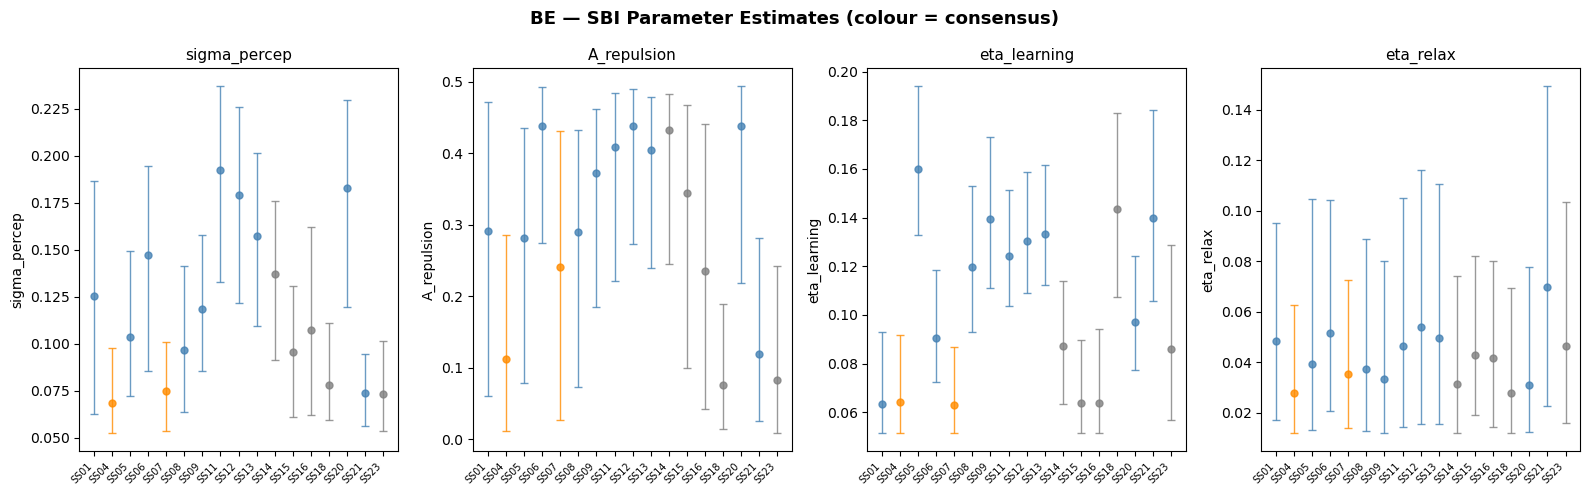

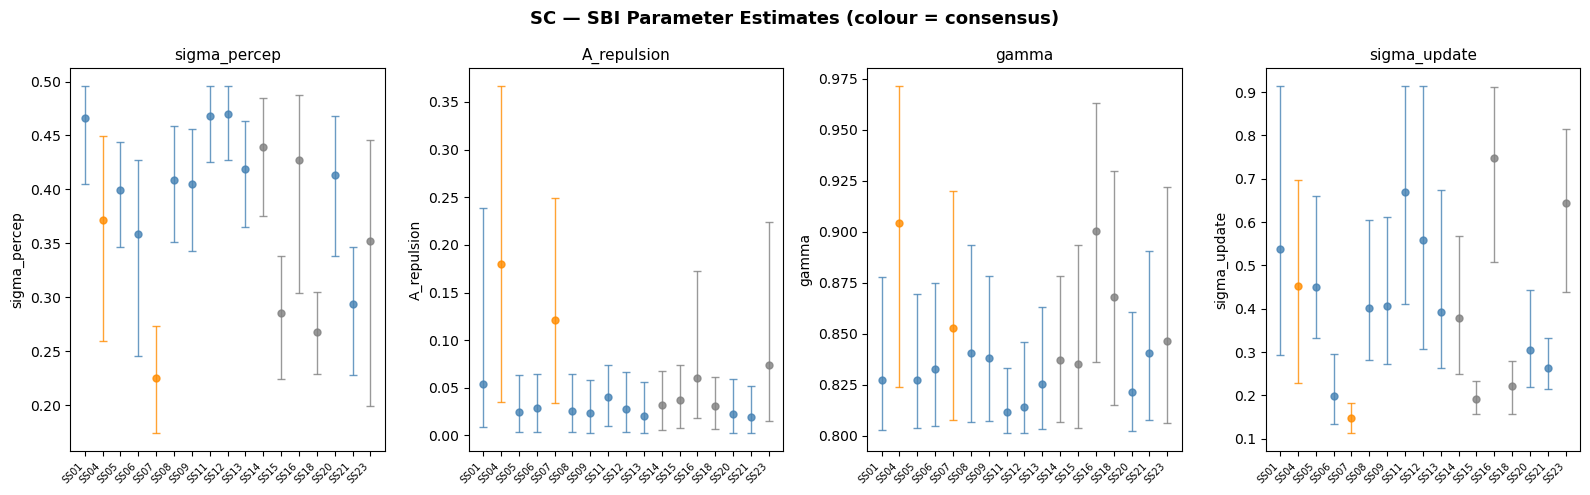

In [11]:
# Plot: parameter distributions, coloured by consensus
if len(param_df) > 0:
    for mt in ['BE', 'SC']:
        sub = param_df[param_df['model'] == mt]
        params = sub['param'].unique()
        n = len(params)

        fig, axes = plt.subplots(1, n, figsize=(4 * n, 5))
        axes = np.atleast_1d(axes)

        for i, pn in enumerate(params):
            ax = axes[i]
            psub = sub[sub['param'] == pn].sort_values('animal_id')

            for j, (_, row) in enumerate(psub.iterrows()):
                cons = row['consensus']
                if cons == 'BE':
                    col = BE_COL
                elif cons == 'SC':
                    col = SC_COL
                else:
                    col = 'grey'

                ax.errorbar(j, row['median'],
                            yerr=[[row['median'] - row['ci_lo']],
                                  [row['ci_hi'] - row['median']]],
                            fmt='o', color=col, ms=5, capsize=3,
                            elinewidth=1, alpha=0.8)

            ax.set_xticks(range(len(psub)))
            ax.set_xticklabels(psub['animal_id'].values,
                               rotation=45, ha='right', fontsize=7)
            ax.set_ylabel(pn)
            ax.set_title(pn, fontsize=11)

        fig.suptitle(f'{mt} — SBI Parameter Estimates (colour = consensus)',
                     fontsize=13, fontweight='bold')
        plt.tight_layout(); plt.show()

---
## 3. GS vs SBI Consistency

For animals with both methods: do the parameter estimates agree?

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

...

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

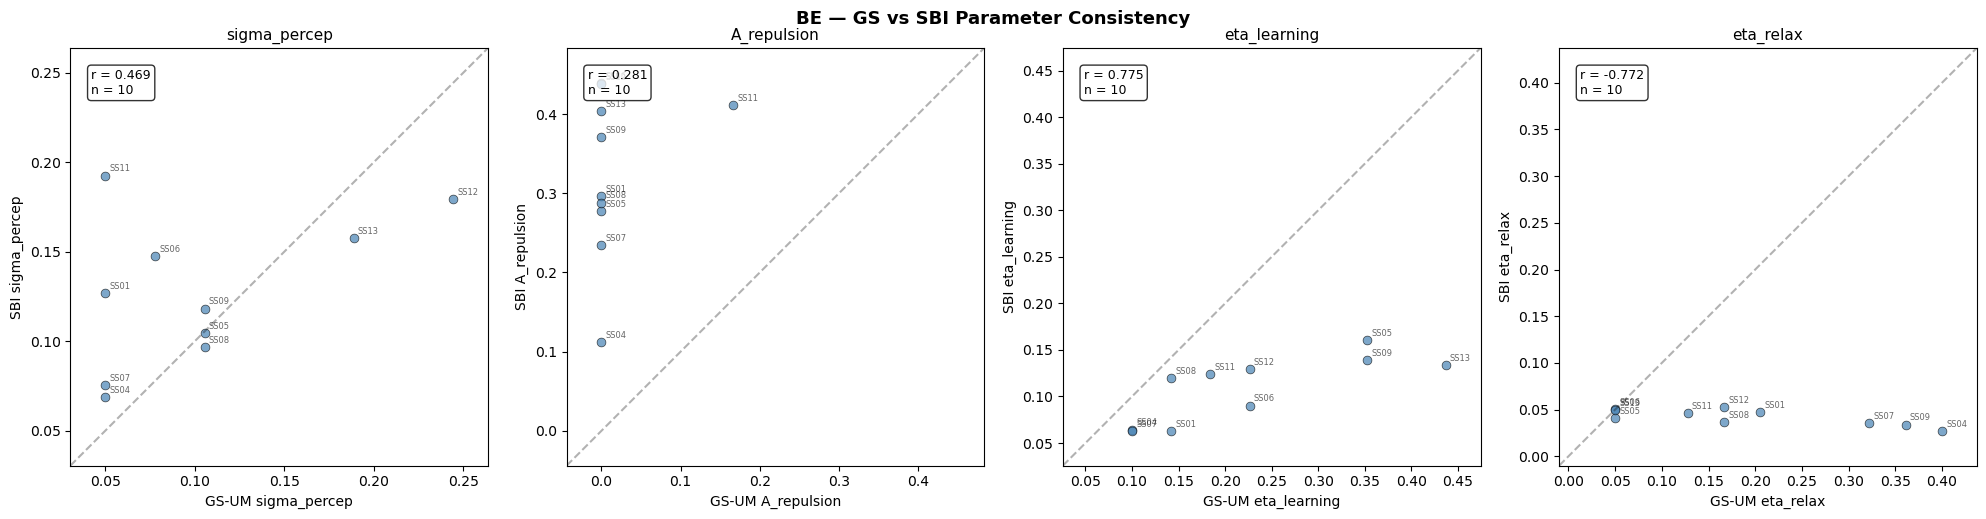

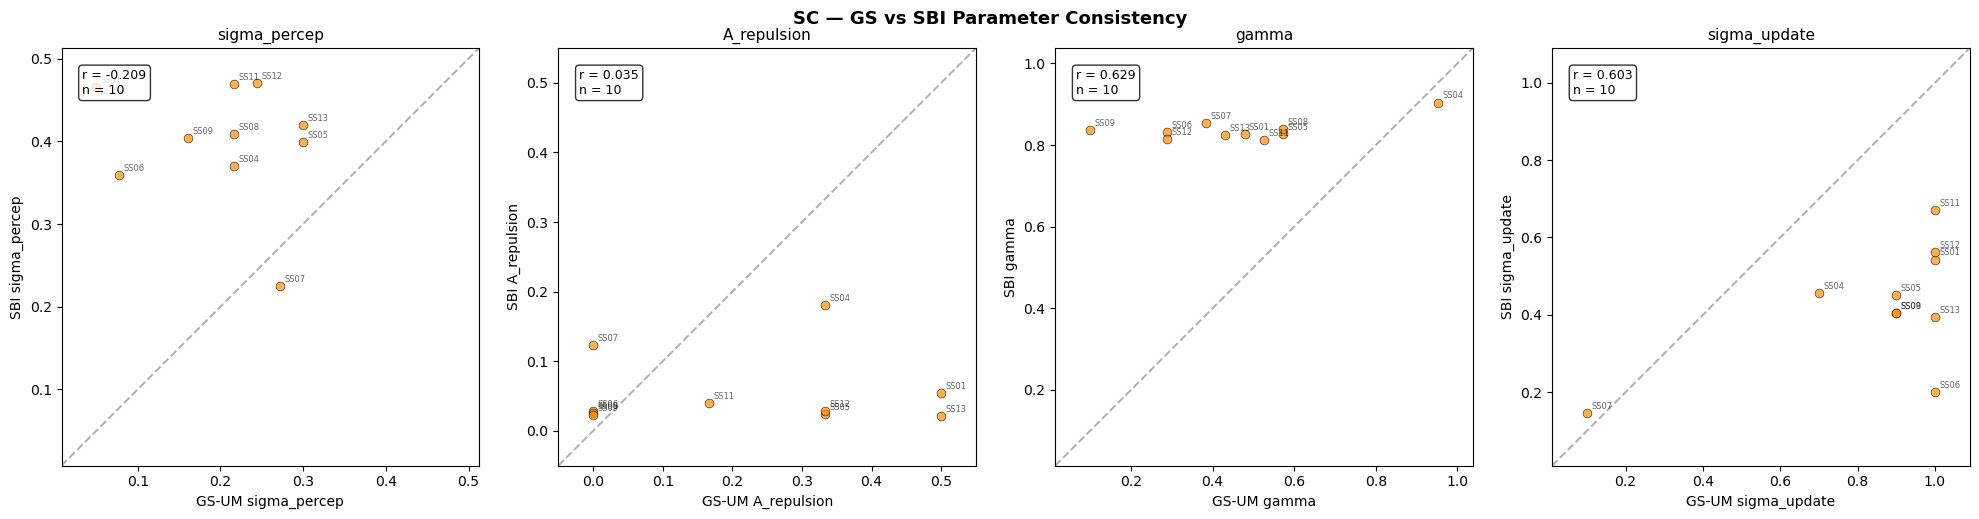

In [7]:
# Load GS best-seed params + SBI posterior medians for shared animals
from plotting.animal_report import _load_gs_raw_pickles, _gs_seed_errors, _get_sbi_samples

consistency_data = {'BE': {}, 'SC': {}}  # {model: {param: {'gs': [], 'sbi': [], 'aid': []}}}

for aid in sorted(experiment.animals.keys()):
    sessions = select_sessions(experiment.animals[aid], 'expert_uniform')
    if len(sessions) < 3: continue

    for ft in ['update_matrix']:  # Use UM fit target for GS
        be_data, sc_data = _load_gs_raw_pickles(aid, RESULTS_DIR, 'uniform', ft)
        if not be_data or not sc_data: continue

        for model_name, gs_data in [('BE', be_data), ('SC', sc_data)]:
            _, gs_params = _gs_seed_errors(gs_data)
            if not gs_params: continue

            # Get SBI params
            mk = model_name.lower()
            if mk not in snpe: continue
            be_samples, sc_samples, _ = _get_sbi_samples(
                aid, sessions, RESULTS_DIR, snpe, 'uniform', n_samples=5000)
            samples = be_samples if mk == 'be' else sc_samples
            if samples is None: continue

            pnames = snpe[mk]['param_names']
            for j, pn in enumerate(pnames):
                if pn not in gs_params: continue
                if pn not in consistency_data[model_name]:
                    consistency_data[model_name][pn] = {'gs': [], 'sbi': [], 'aid': []}
                consistency_data[model_name][pn]['gs'].append(gs_params[pn])
                consistency_data[model_name][pn]['sbi'].append(np.median(samples[:, j]))
                consistency_data[model_name][pn]['aid'].append(aid)

# Plot
for mt in ['BE', 'SC']:
    params = consistency_data.get(mt, {})
    if not params: continue
    pnames = list(params.keys())
    n = len(pnames)
    col = BE_COL if mt == 'BE' else SC_COL

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    axes = np.atleast_1d(axes)

    for i, pn in enumerate(pnames):
        ax = axes[i]
        gs_vals = np.array(params[pn]['gs'])
        sbi_vals = np.array(params[pn]['sbi'])
        aids = params[pn]['aid']

        ax.scatter(gs_vals, sbi_vals, color=col, s=40, alpha=0.7,
                   edgecolors='black', lw=0.5)

        # Label each point
        for g, s, a in zip(gs_vals, sbi_vals, aids):
            ax.annotate(a, (g, s), fontsize=6, alpha=0.6,
                        xytext=(3, 3), textcoords='offset points')

        # Identity line
        all_v = np.concatenate([gs_vals, sbi_vals])
        lo, hi = all_v.min(), all_v.max()
        m = (hi - lo) * 0.1
        lims = [lo - m, hi + m]
        ax.plot(lims, lims, 'k--', alpha=0.3)

        r = np.corrcoef(gs_vals, sbi_vals)[0, 1] if len(gs_vals) > 2 else np.nan
        ax.text(0.05, 0.95, f'r = {r:.3f}\nn = {len(gs_vals)}',
                transform=ax.transAxes, fontsize=9, va='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        ax.set(xlabel=f'GS-UM {pn}', ylabel=f'SBI {pn}', aspect='equal')
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_title(pn, fontsize=11)

    fig.suptitle(f'{mt} — GS vs SBI Parameter Consistency',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

---
## 4. Example Animal Deep-Dives

Change `EXAMPLE_ANIMALS` at the top to pick different animals.


══════════════════════════════════════════════════════════════════════
  SS05
══════════════════════════════════════════════════════════════════════


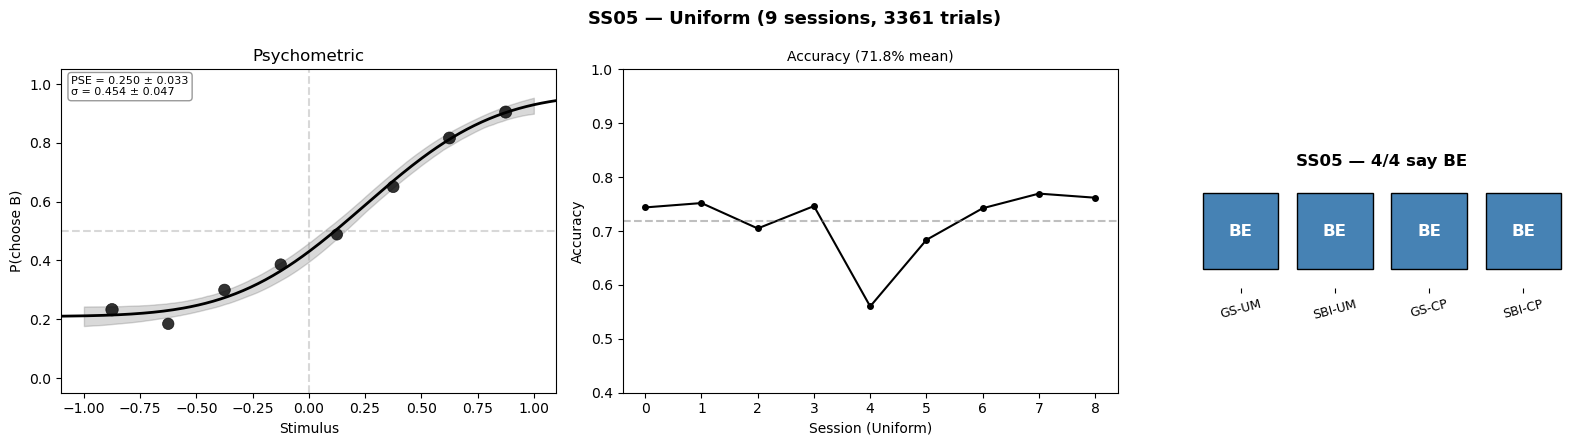

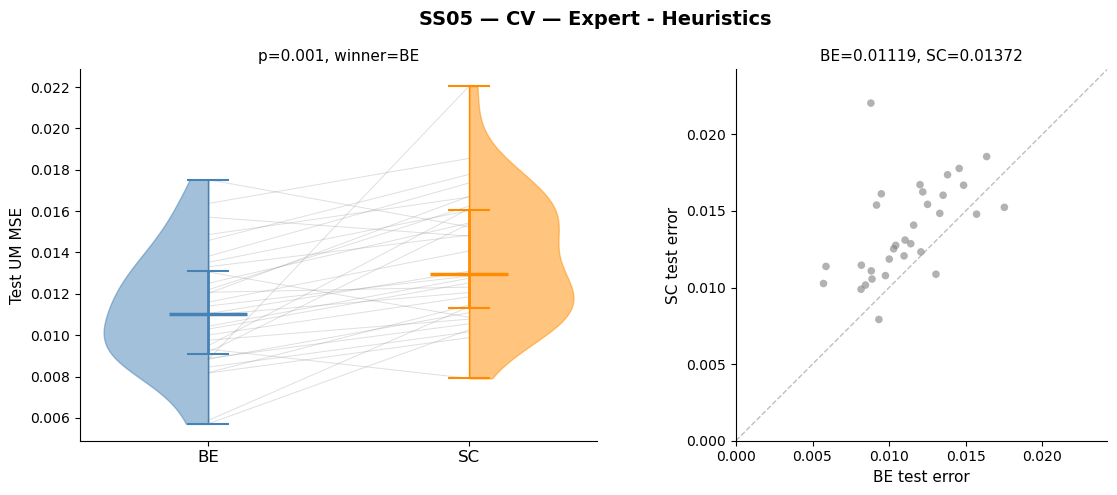

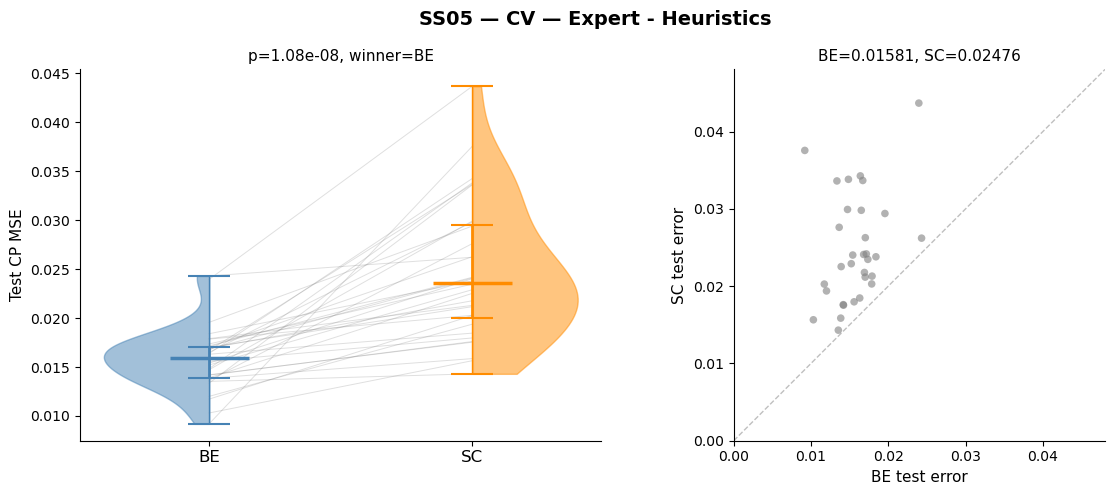

  SS05: params from SBI-UM
    BE: sigma_percep=0.095, A_repulsion=0.204, eta_learning=0.194, eta_relax=0.059
    SC: sigma_percep=0.420, A_repulsion=0.033, gamma=0.824, sigma_update=0.536
  Simulating (9 sessions, 20 reps)...
  9 sessions done


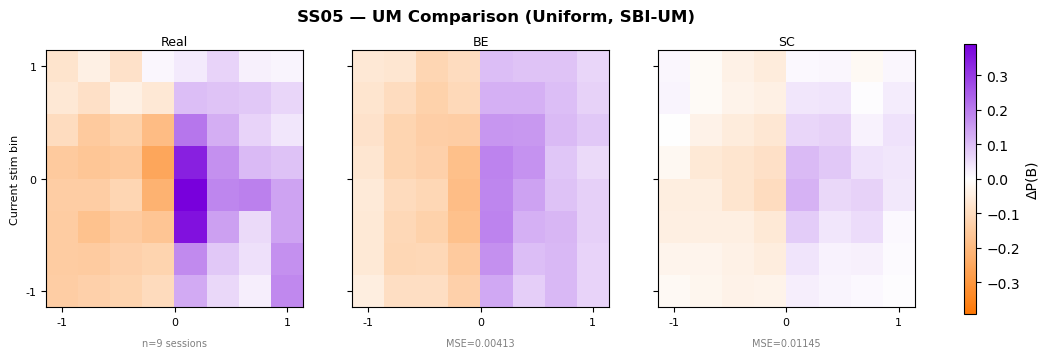

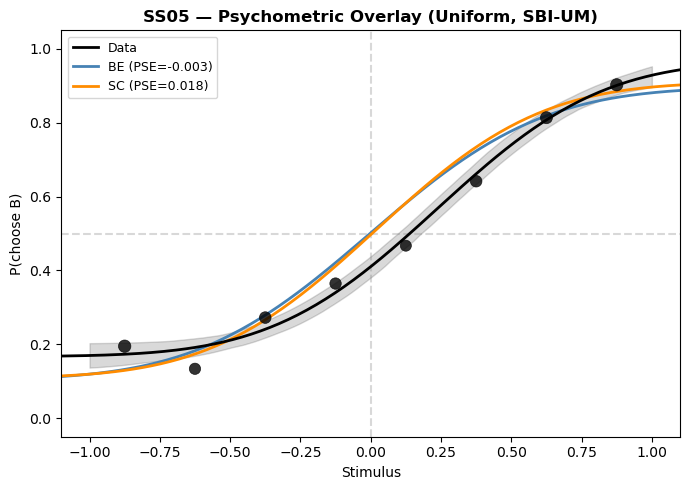


  Psychometric parameter comparison:
                        PSE     Slope (σ)     Lapse low    Lapse high
  Data                0.237         0.461         0.167         0.032
  BE                 -0.003         0.485         0.104         0.104
  SC                  0.018         0.461         0.108         0.090


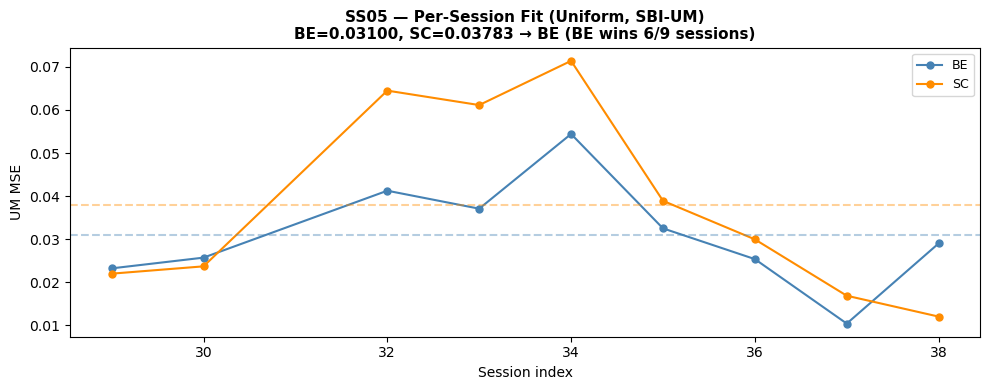

  SS05: params from GS-UM
    BE: sigma_percep=0.106, A_repulsion=0.000, eta_learning=0.353, eta_relax=0.050
    SC: sigma_percep=0.300, A_repulsion=0.333, gamma=0.574, sigma_update=0.900
  Simulating (9 sessions, 20 reps)...


/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/inference/comparison.py:629: RuntimeWarning: Mean of empty slice
  be_mean_um = (np.nanmean(be_ums, axis=0) if be_ums


  9 sessions done


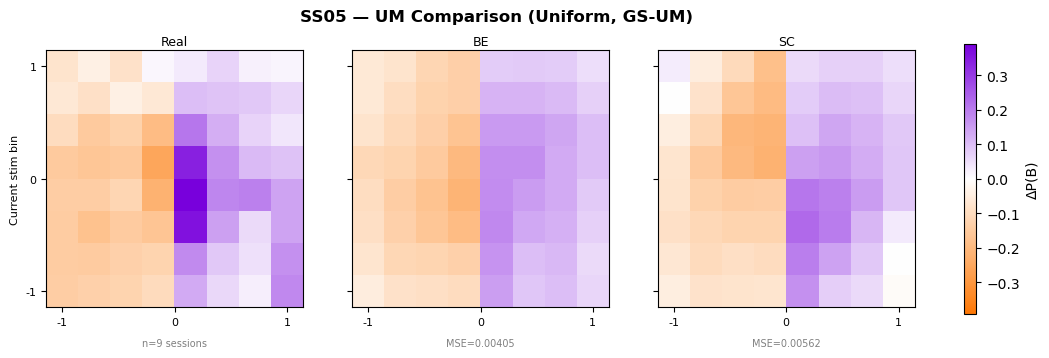

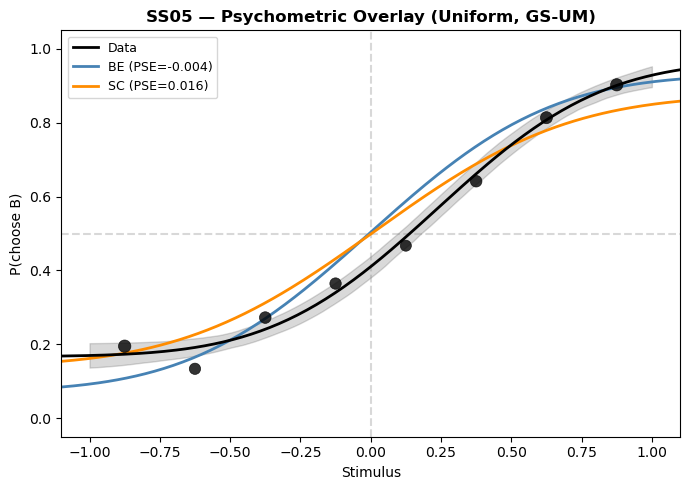


  Psychometric parameter comparison:
                        PSE     Slope (σ)     Lapse low    Lapse high
  Data                0.237         0.461         0.167         0.032
  BE                 -0.004         0.504         0.072         0.070
  SC                  0.016         0.541         0.140         0.125


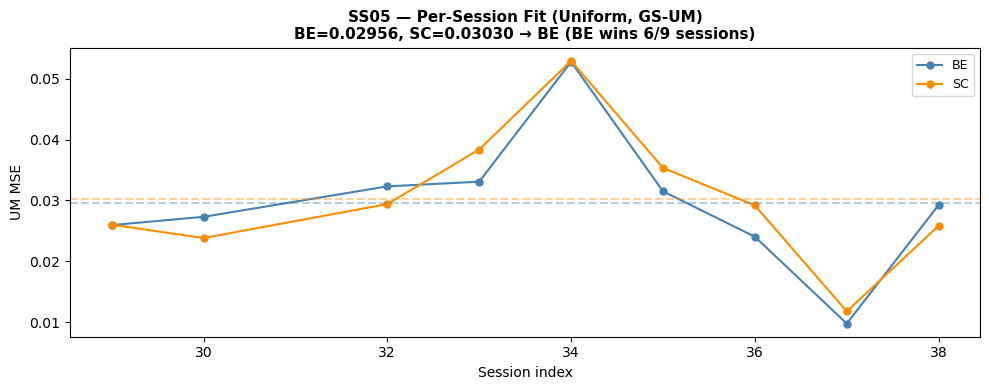

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

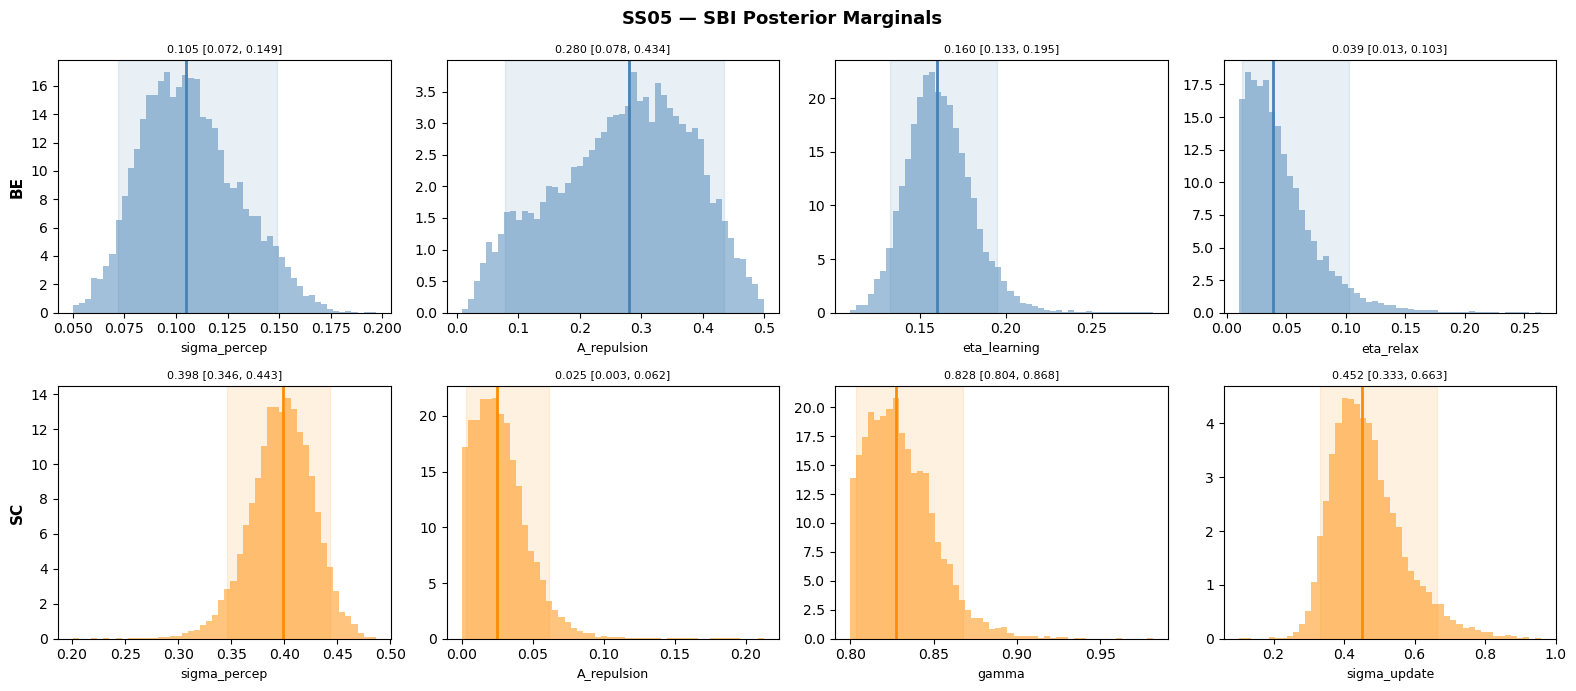

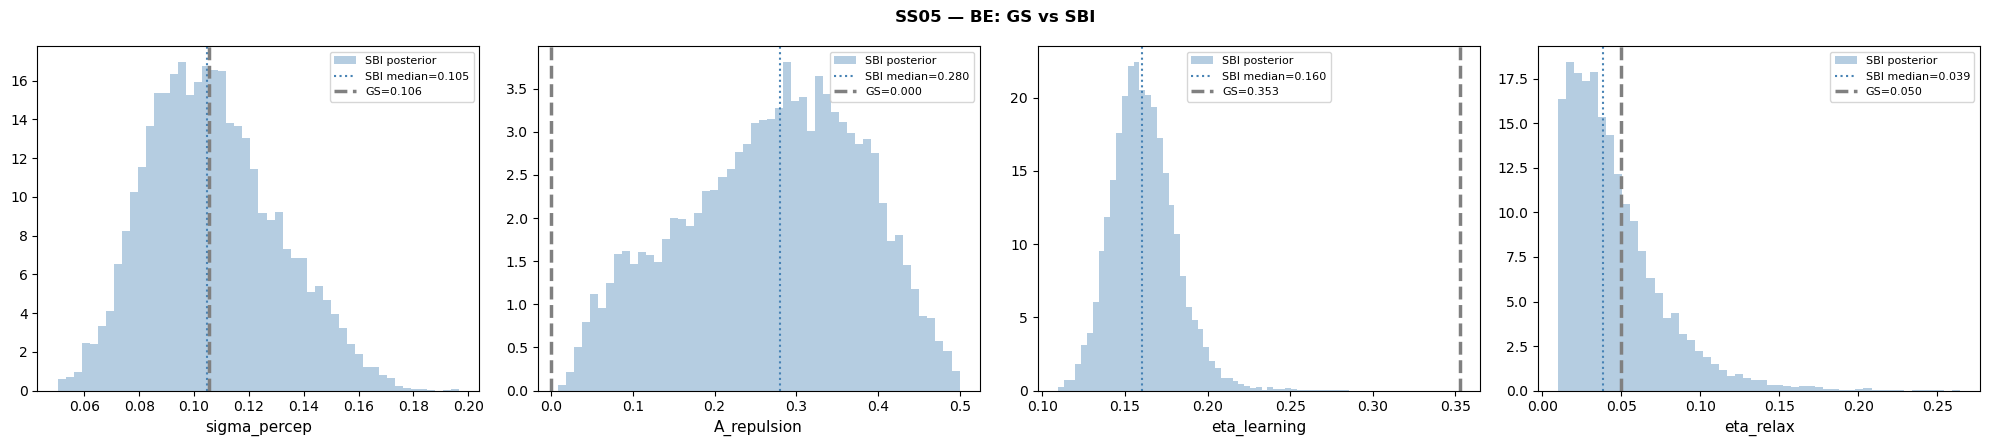

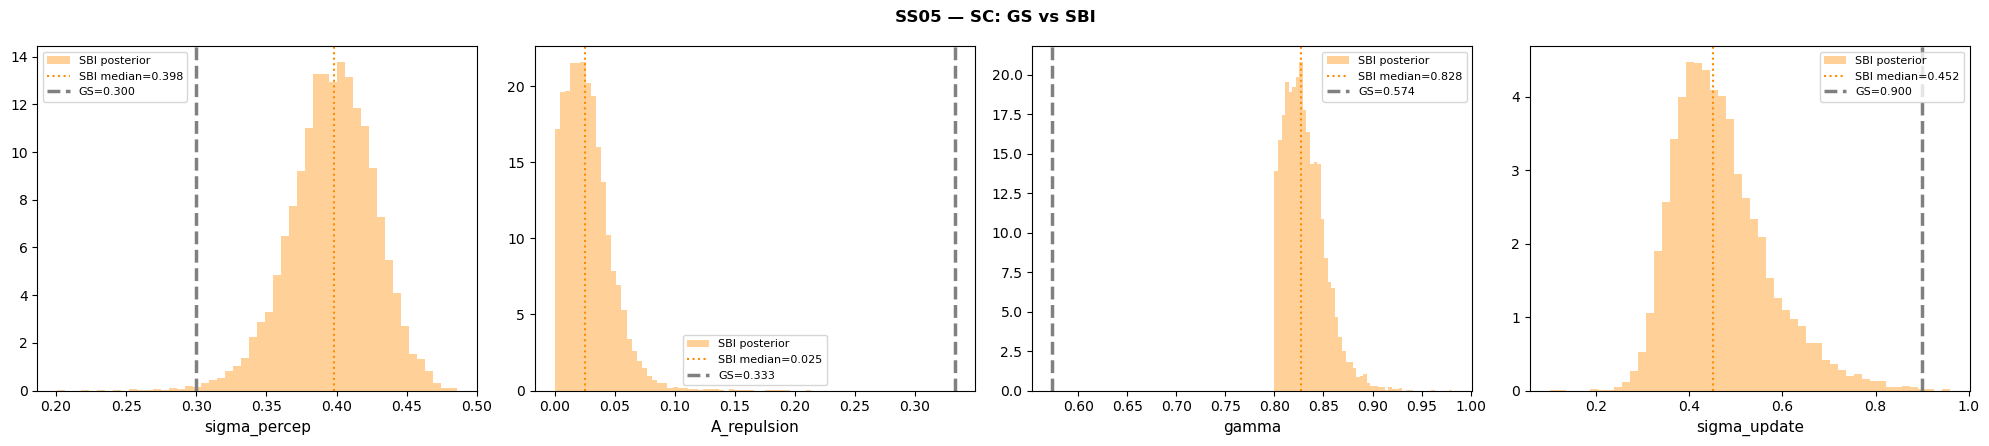

  BE PPC: all simulations failed
  SC PPC: all simulations failed

══════════════════════════════════════════════════════════════════════
  SS07
══════════════════════════════════════════════════════════════════════


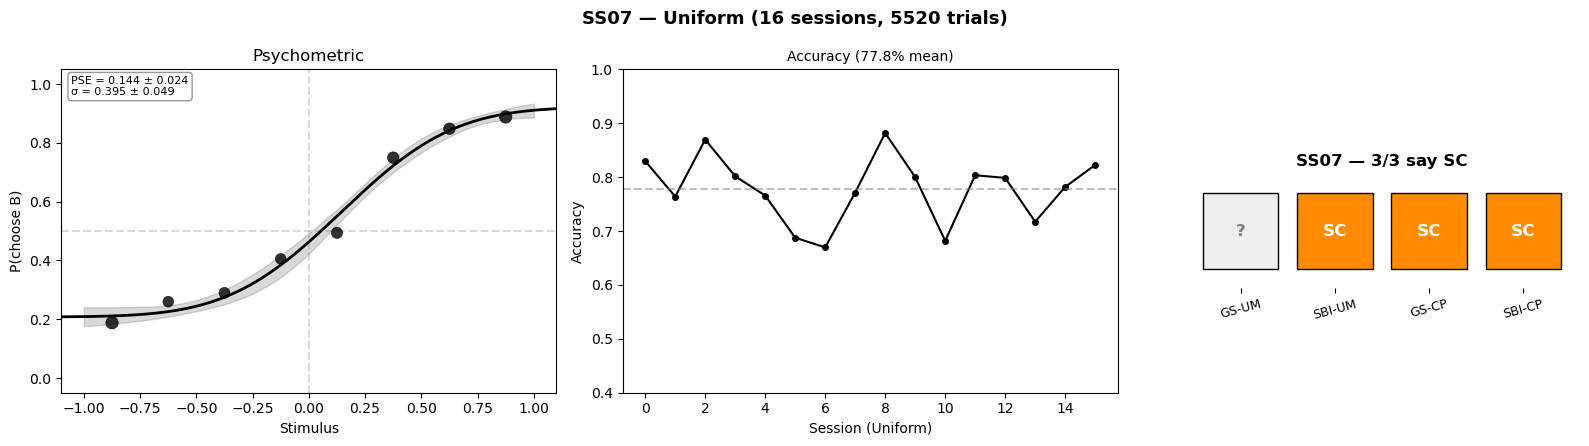

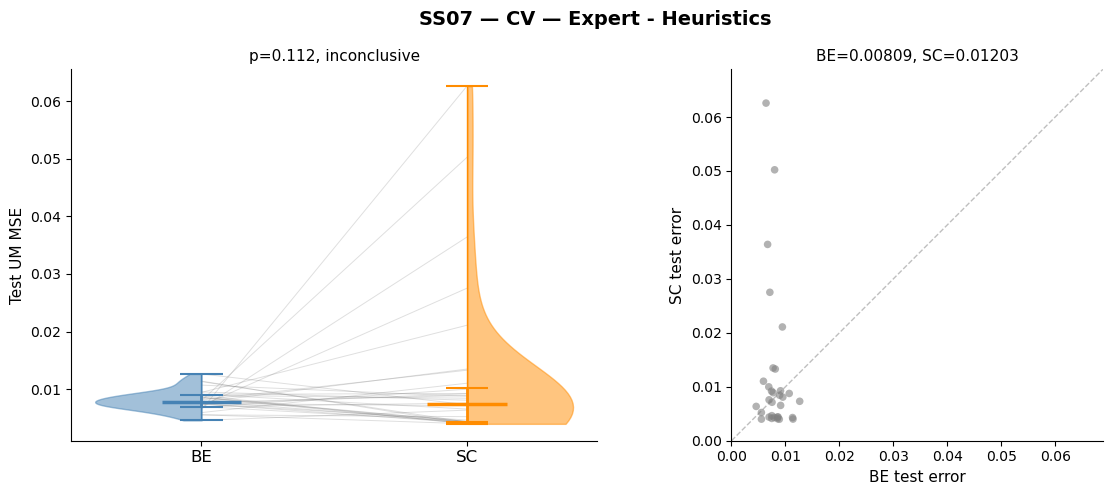

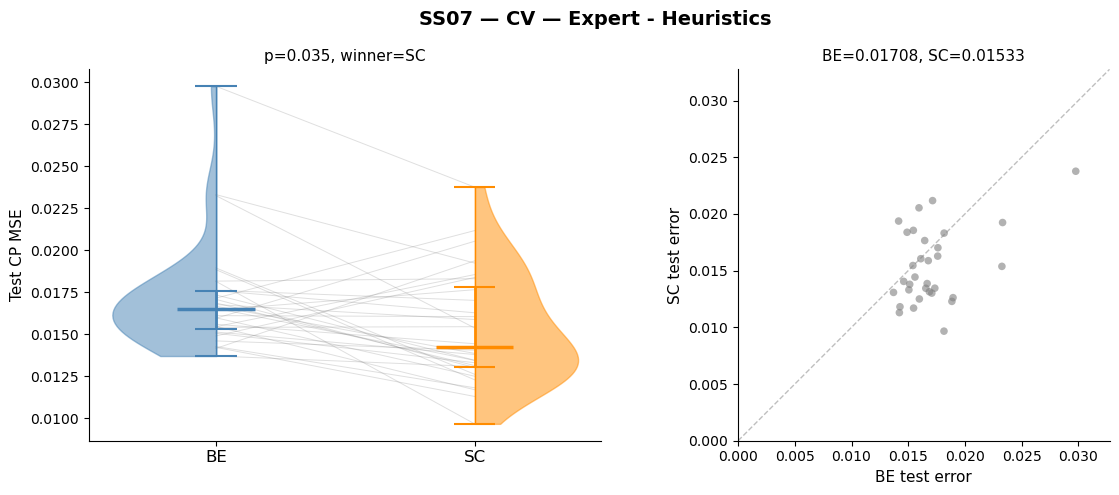

  SS07: params from SBI-UM
    BE: sigma_percep=0.057, A_repulsion=0.017, eta_learning=0.087, eta_relax=0.093
    SC: sigma_percep=0.277, A_repulsion=0.240, gamma=0.863, sigma_update=0.500
  Simulating (16 sessions, 20 reps)...


/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/inference/comparison.py:629: RuntimeWarning: Mean of empty slice
  be_mean_um = (np.nanmean(be_ums, axis=0) if be_ums
/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/inference/comparison.py:638: RuntimeWarning: Mean of empty slice
  sc_mean_um = (np.nanmean(sc_ums, axis=0) if sc_ums


  16 sessions done


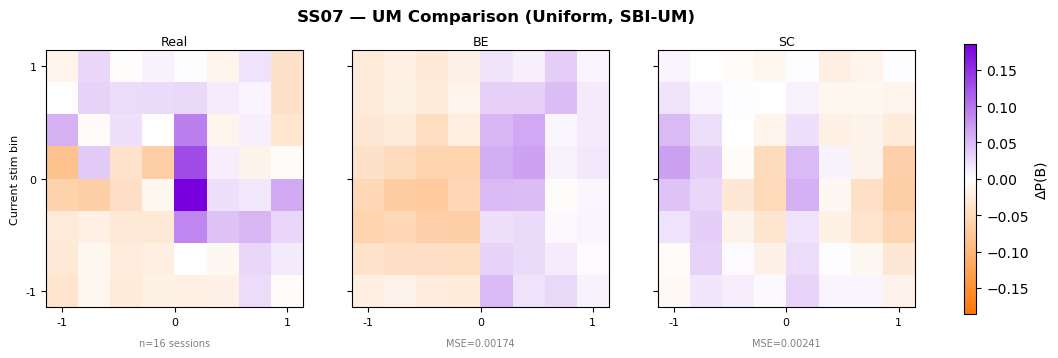

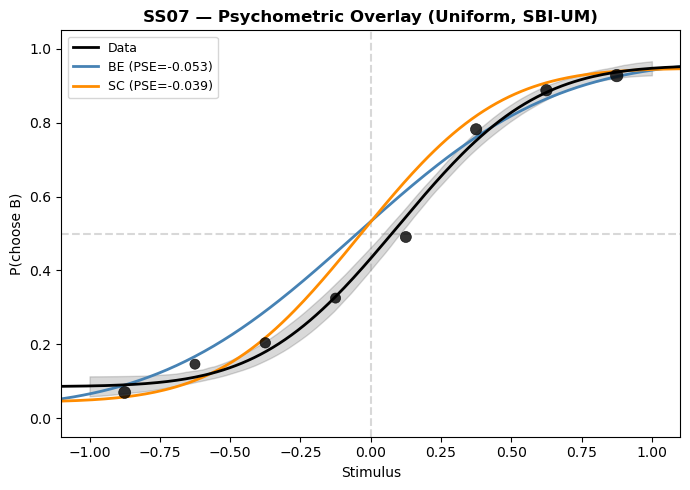


  Psychometric parameter comparison:
                        PSE     Slope (σ)     Lapse low    Lapse high
  Data                0.098         0.383         0.086         0.045
  BE                 -0.053         0.555         0.025         0.030
  SC                 -0.039         0.387         0.044         0.053


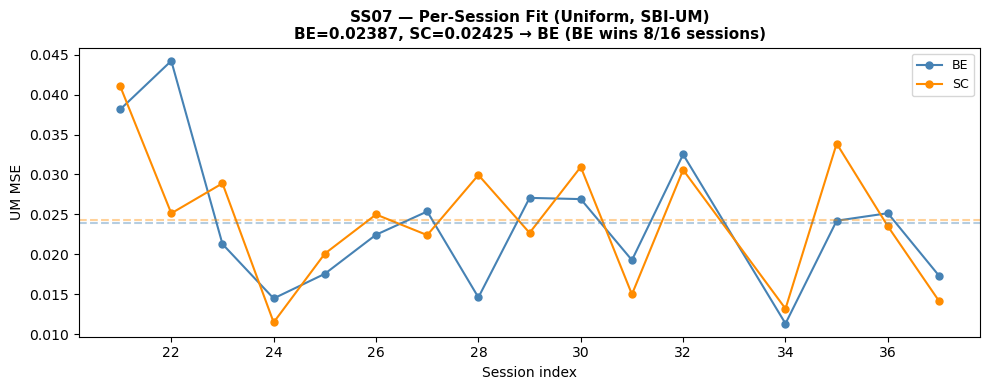

  SS07: params from GS-UM
    BE: sigma_percep=0.050, A_repulsion=0.000, eta_learning=0.100, eta_relax=0.322
    SC: sigma_percep=0.272, A_repulsion=0.000, gamma=0.384, sigma_update=0.100
  Simulating (16 sessions, 20 reps)...


/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/inference/comparison.py:629: RuntimeWarning: Mean of empty slice
  be_mean_um = (np.nanmean(be_ums, axis=0) if be_ums


  16 sessions done


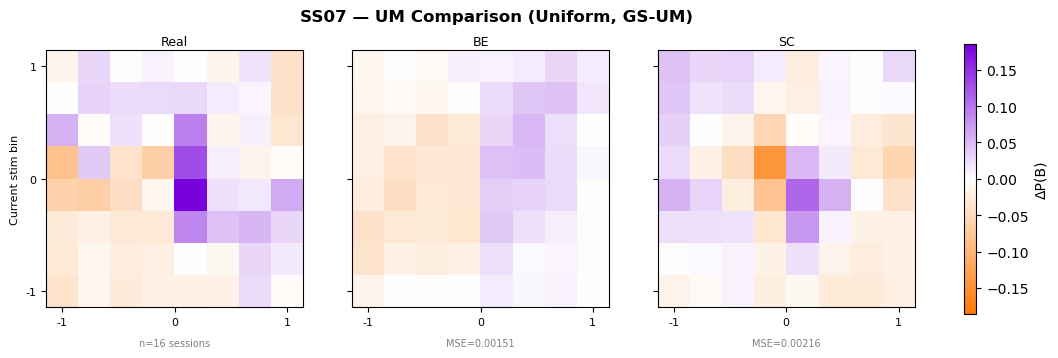

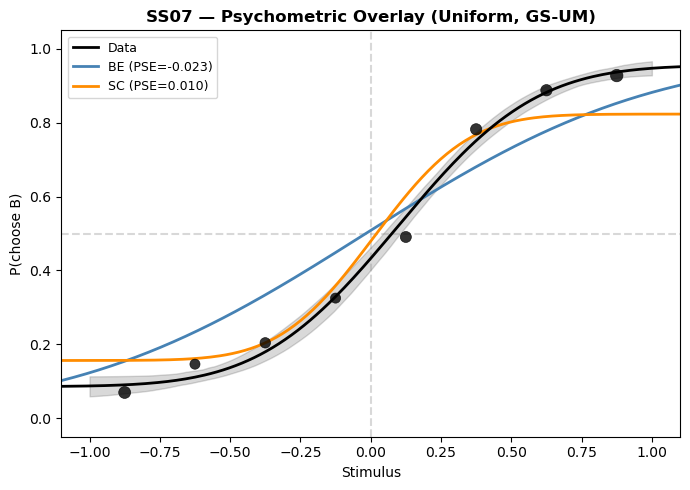


  Psychometric parameter comparison:
                        PSE     Slope (σ)     Lapse low    Lapse high
  Data                0.098         0.383         0.086         0.045
  BE                 -0.023         0.802         0.016         0.021
  SC                  0.010         0.263         0.156         0.177


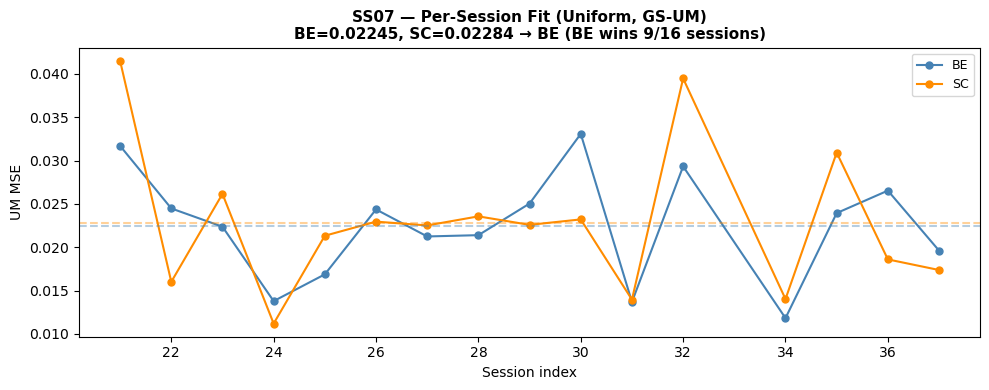

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

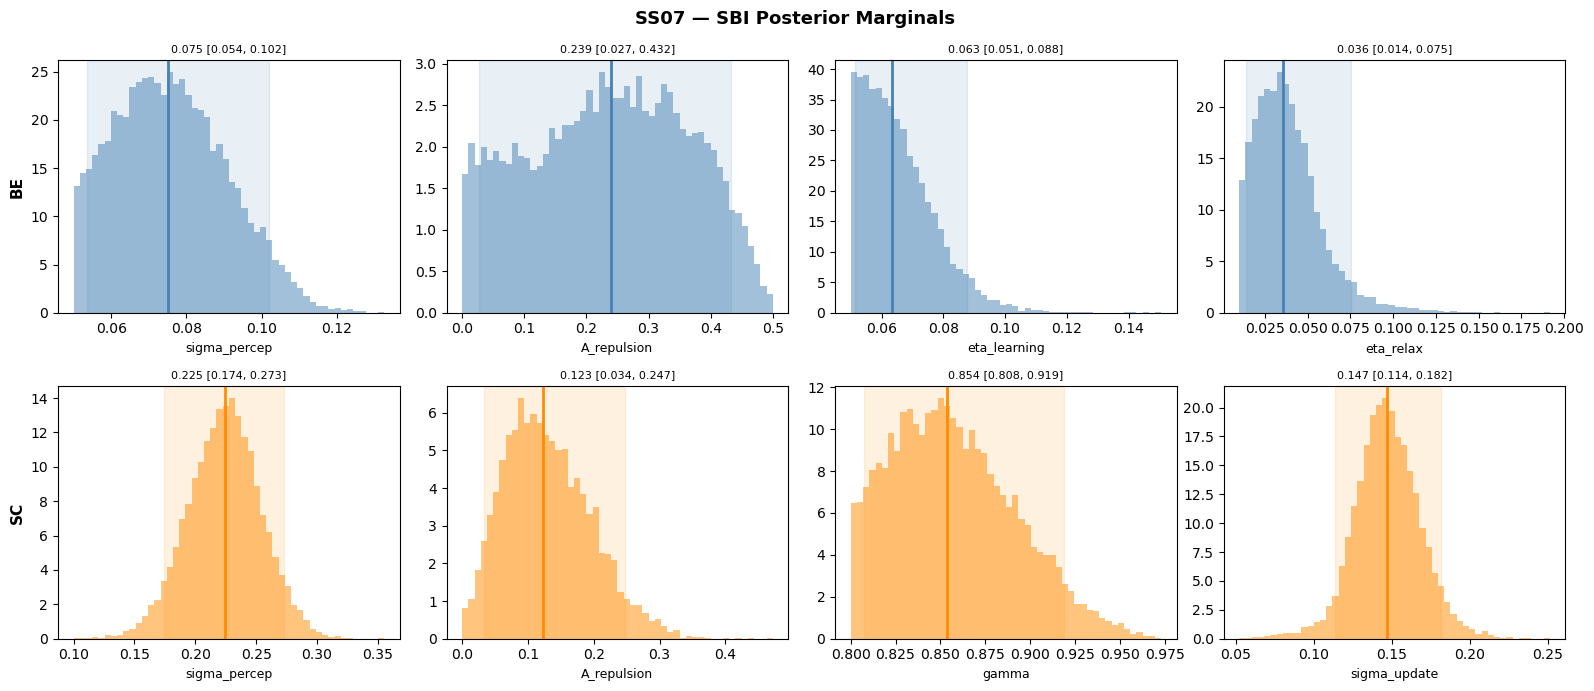

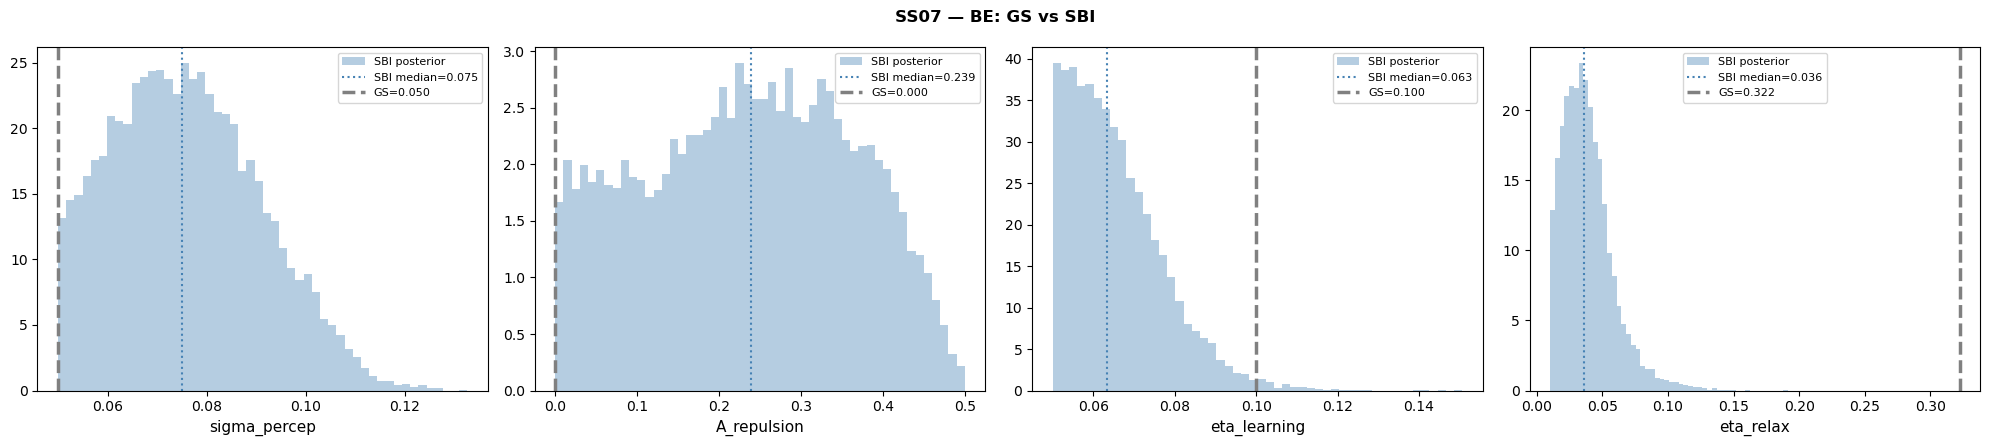

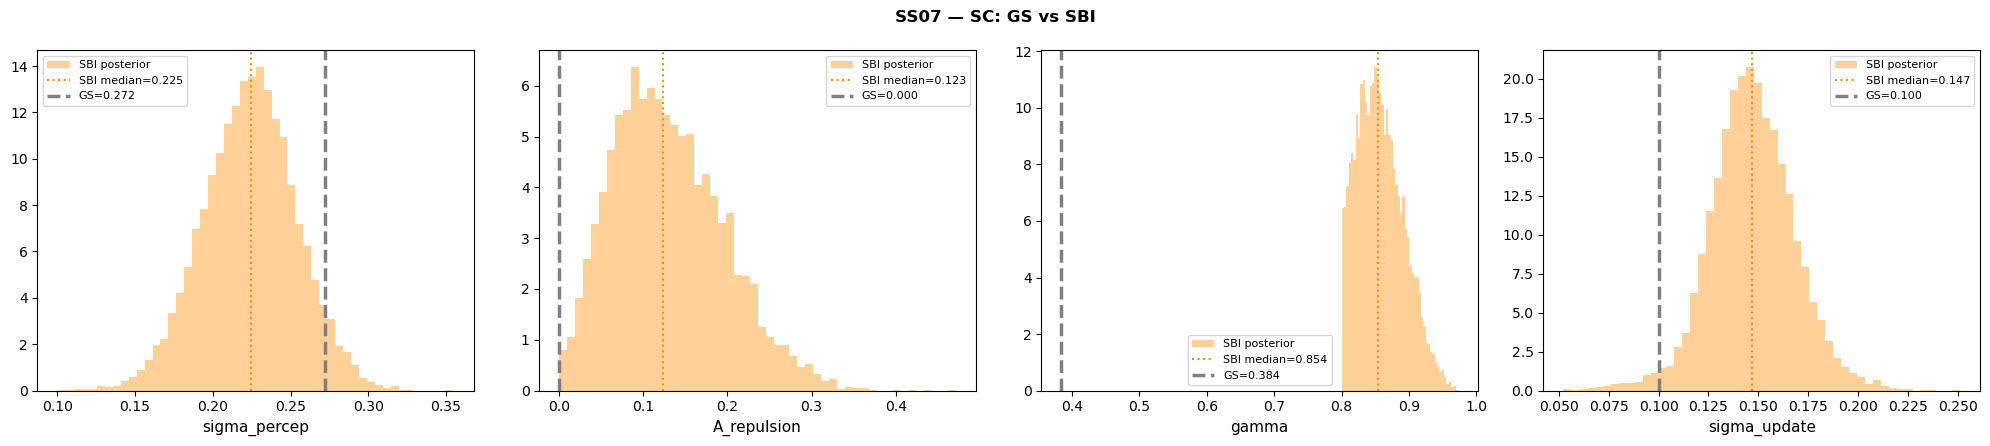

  BE PPC: all simulations failed
  SC PPC: all simulations failed


In [8]:
for AID in EXAMPLE_ANIMALS:
    print(f'\n{"═" * 70}')
    print(f'  {AID}')
    print(f'{"═" * 70}')

    if AID not in experiment.animals:
        print(f'{AID} not found'); continue

    sessions = select_sessions(experiment.animals[AID], 'expert_uniform')
    if not sessions:
        print('No expert uniform sessions'); continue

    # Raw behaviour + consensus strip
    plot_animal_summary(AID, sessions, RESULTS_DIR)

    # GS CV — both fit targets
    for ft in FIT_TARGETS:
        plot_cv_results(AID, RESULTS_DIR, fit_target=ft)

    # Model fits — SBI params (primary)
    plot_model_fits(AID, sessions, RESULTS_DIR, method='sbi')

    # Model fits — GS params (comparison)
    plot_model_fits(AID, sessions, RESULTS_DIR, method='gs')

    # SBI diagnostics
    plot_sbi_diagnostics(AID, sessions, snpe, RESULTS_DIR)

---
## 5. Dynamic SBI — Parameter Trajectories

Preliminary: how do parameters evolve across sessions during
expert performance? (Real test comes post-shift.)


SS05 BE (9 sessions, varying: ['eta_learning', 'eta_relax'])
  sigma_percep         constant = 0.426
  A_repulsion          constant = 0.039
  eta_learning         0.592 → 0.579 (Δ=-0.013)
  eta_relax            0.315 → 0.260 (Δ=-0.054)


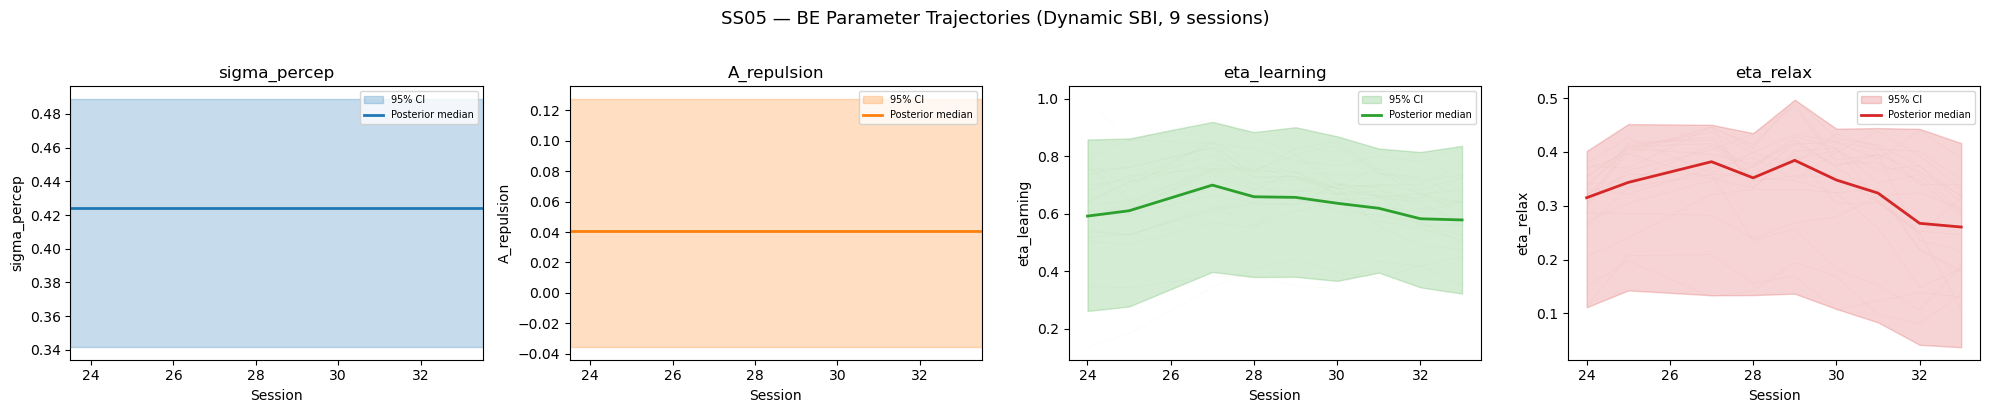


SS05 SC (9 sessions, varying: ['gamma', 'sigma_update'])
  sigma_percep         constant = 0.408
  A_repulsion          constant = 0.009
  gamma                0.867 → 0.885 (Δ=+0.018)
  sigma_update         0.711 → 0.615 (Δ=-0.097)


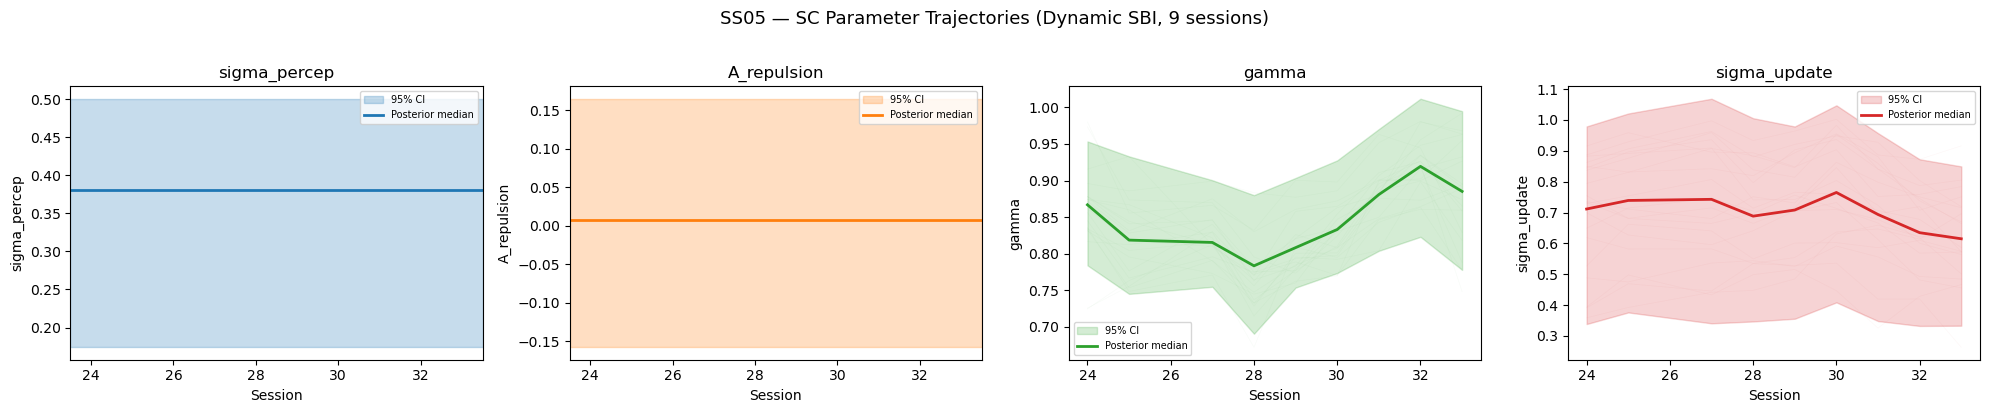


SS07 BE (16 sessions, varying: ['eta_learning', 'eta_relax'])
  sigma_percep         constant = 0.084
  A_repulsion          constant = 0.248
  eta_learning         0.179 → 0.164 (Δ=-0.014)
  eta_relax            0.369 → 0.340 (Δ=-0.029)


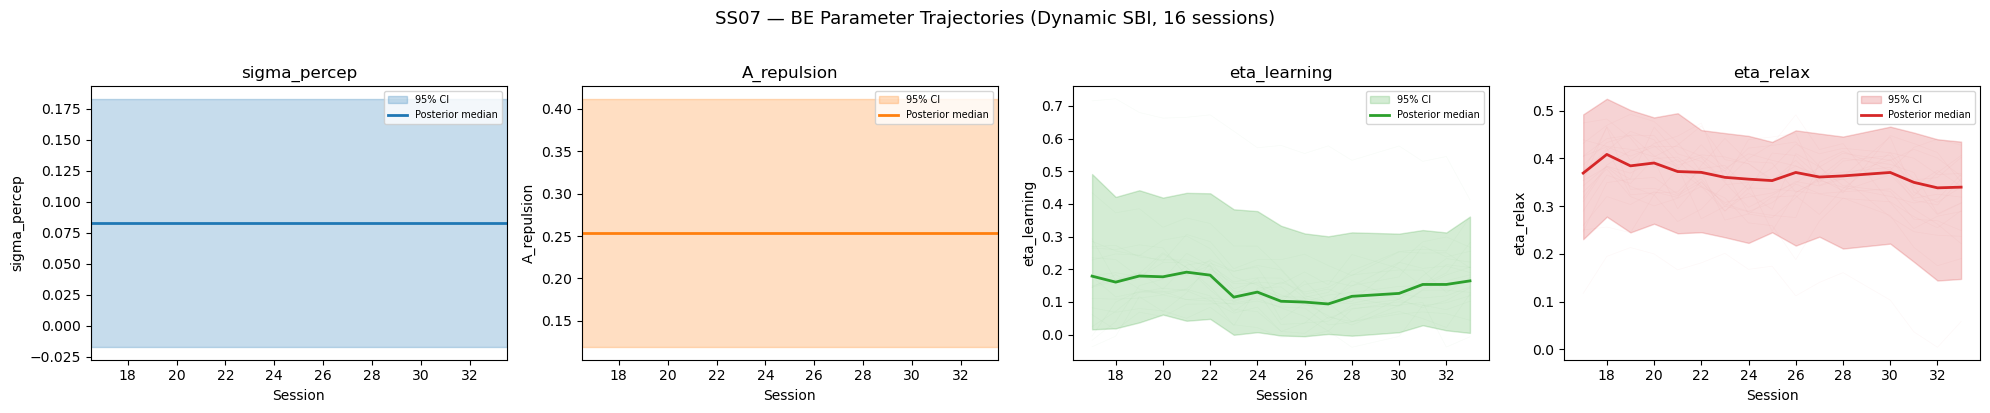


SS07 SC (16 sessions, varying: ['gamma', 'sigma_update'])
  sigma_percep         constant = 0.280
  A_repulsion          constant = 0.025
  gamma                0.902 → 0.999 (Δ=+0.096)
  sigma_update         0.420 → 0.399 (Δ=-0.021)


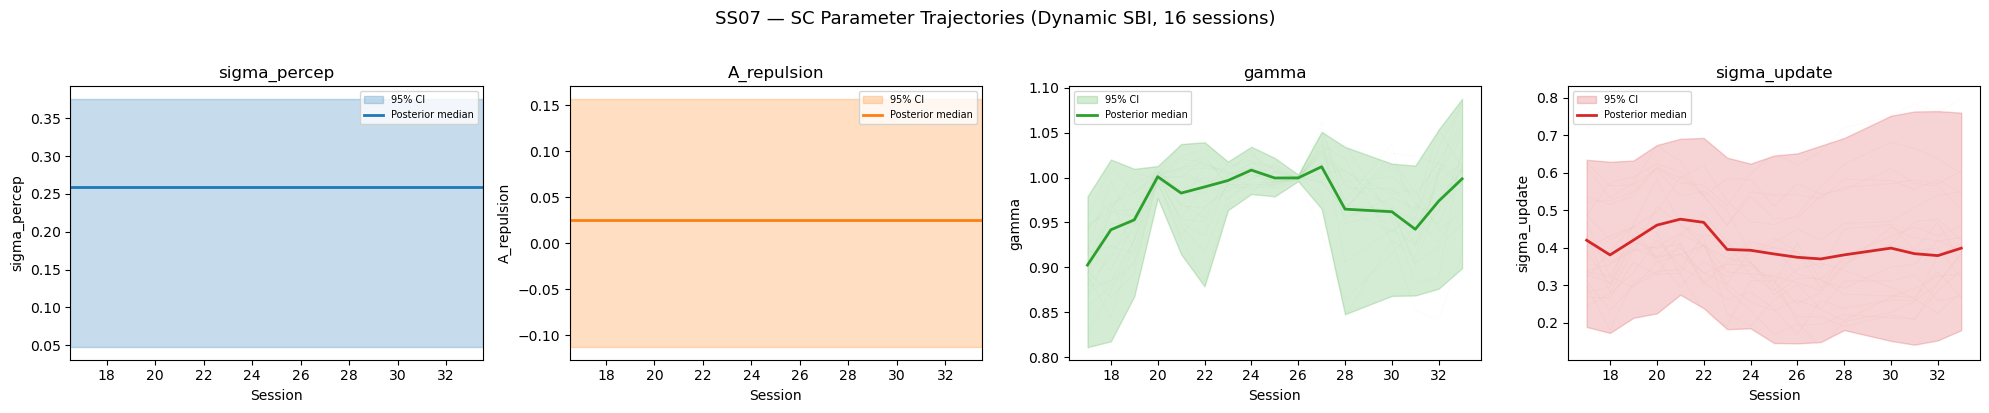

In [9]:
from plotting.sbi import plot_parameter_trajectories

DYN_DIR = RESULTS_DIR / 'sbi_dynamic' / 'uniform_update_matrix'

if DYN_DIR.exists():
    dyn_files = sorted(DYN_DIR.glob('*.pkl'))
    dyn_files = [f for f in dyn_files if f.name != 'summary.pkl']

    # Show for example animals
    for AID in EXAMPLE_ANIMALS:
        for model in ['BE', 'SC']:
            p = DYN_DIR / f'{AID}_{model}.pkl'
            if not p.exists(): continue
            with open(p, 'rb') as f: d = pickle.load(f)

            varying = d['varying_params']
            print(f'\n{AID} {model} ({d["n_sessions"]} sessions, '
                  f'varying: {varying})')

            # Print trajectory summary
            for pn, traj in d['trajectories'].items():
                med = traj['median']
                if isinstance(med, np.ndarray) and len(med) > 1:
                    print(f'  {pn:20s} {med[0]:.3f} → {med[-1]:.3f} '
                          f'(Δ={med[-1]-med[0]:+.3f})')
                else:
                    val = med if np.isscalar(med) else med[0]
                    print(f'  {pn:20s} constant = {val:.3f}')

            fig = plot_parameter_trajectories(
                d['trajectories'],
                title=f'{AID} — {model} Parameter Trajectories '
                      f'(Dynamic SBI, {d["n_sessions"]} sessions)',
                show_samples=20,
            )
            plt.show()
else:
    print('No dynamic SBI results found')

---
## 6. Drill-Down: Any Animal

Change `INSPECT_ID` and re-run this cell.

Inspecting SS04 (22 expert sessions)


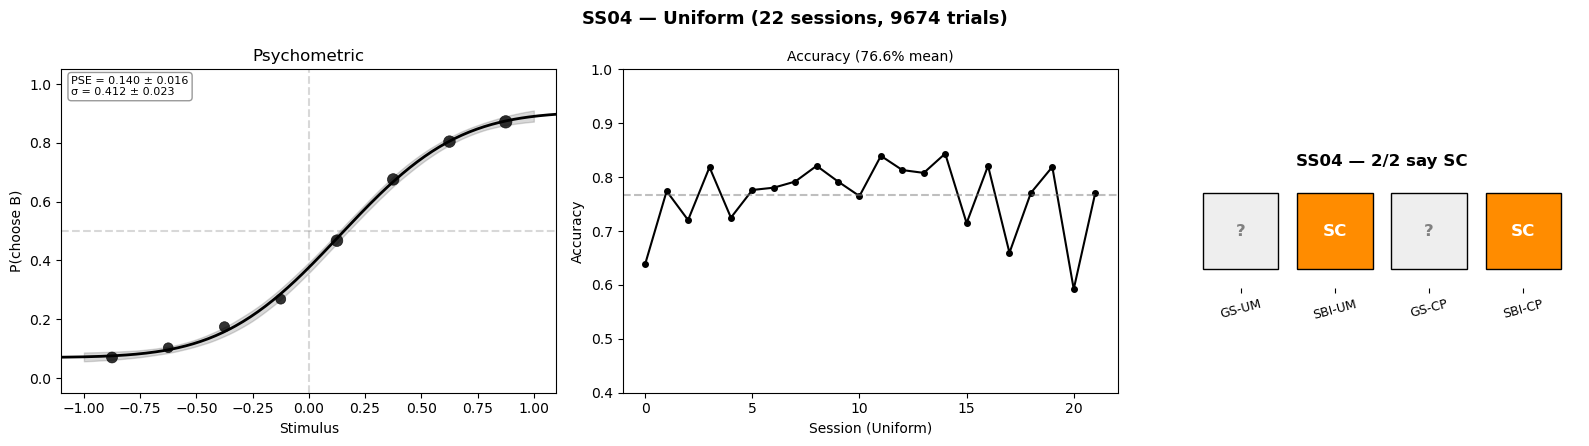

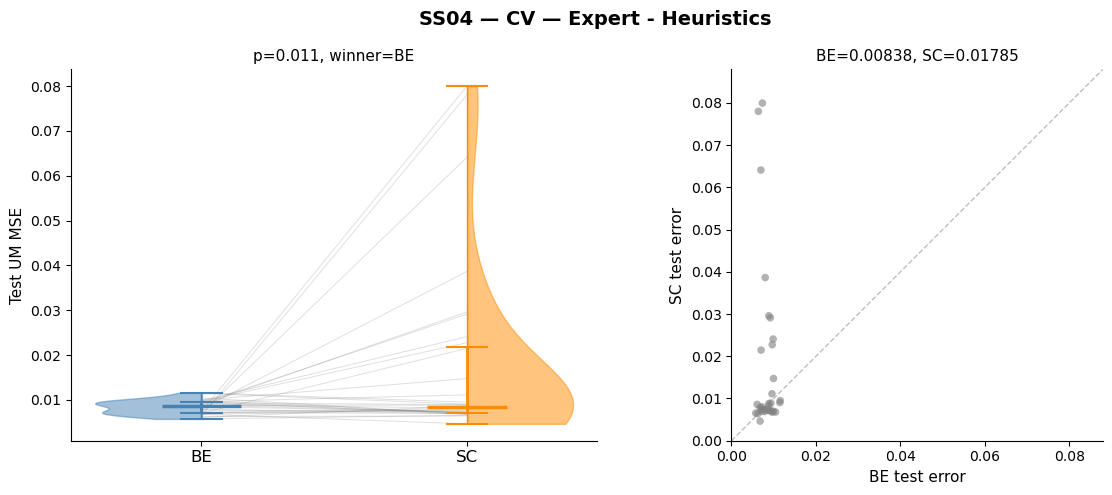

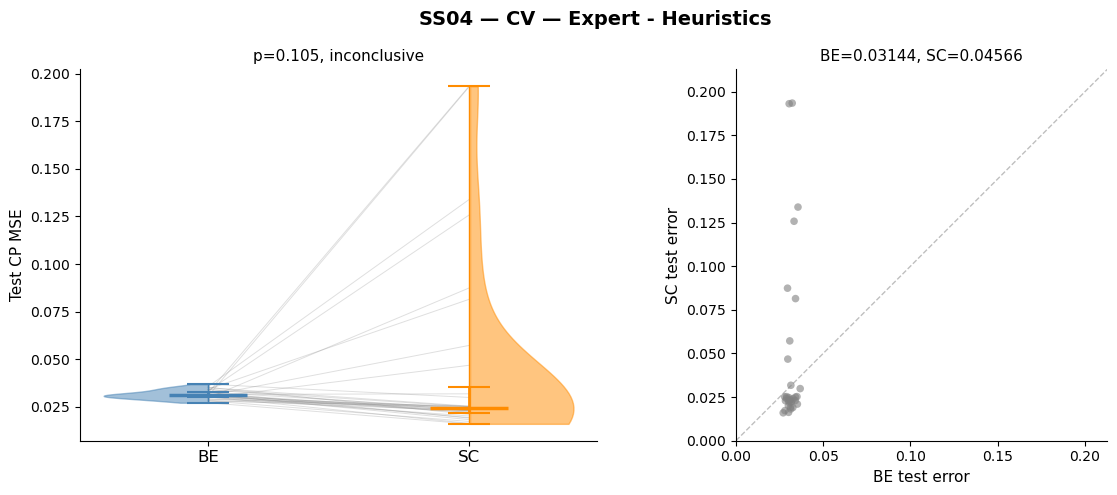

  SS04: params from SBI-UM
    BE: sigma_percep=0.060, A_repulsion=0.023, eta_learning=0.078, eta_relax=0.051
    SC: sigma_percep=0.345, A_repulsion=0.322, gamma=0.926, sigma_update=0.403
  Simulating (22 sessions, 20 reps)...
  22 sessions done


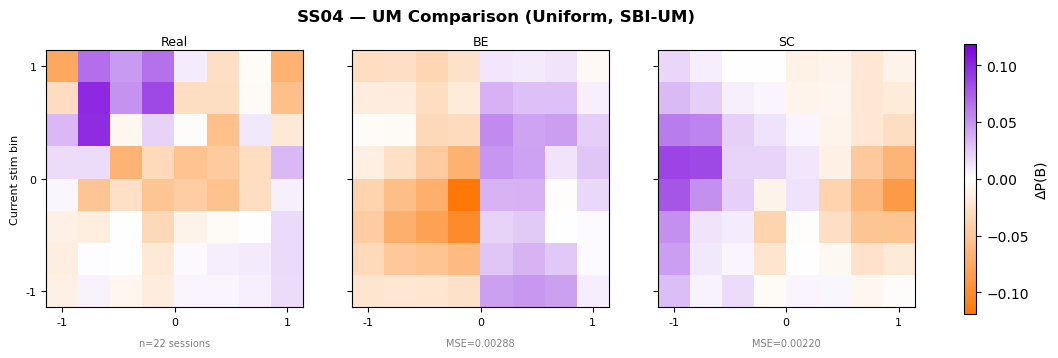

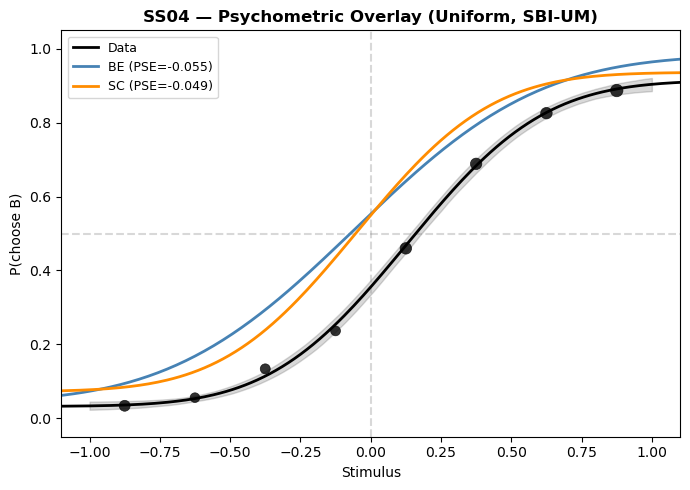


  Psychometric parameter comparison:
                        PSE     Slope (σ)     Lapse low    Lapse high
  Data                0.131         0.382         0.032         0.086
  BE                 -0.055         0.515         0.042         0.016
  SC                 -0.049         0.376         0.072         0.064


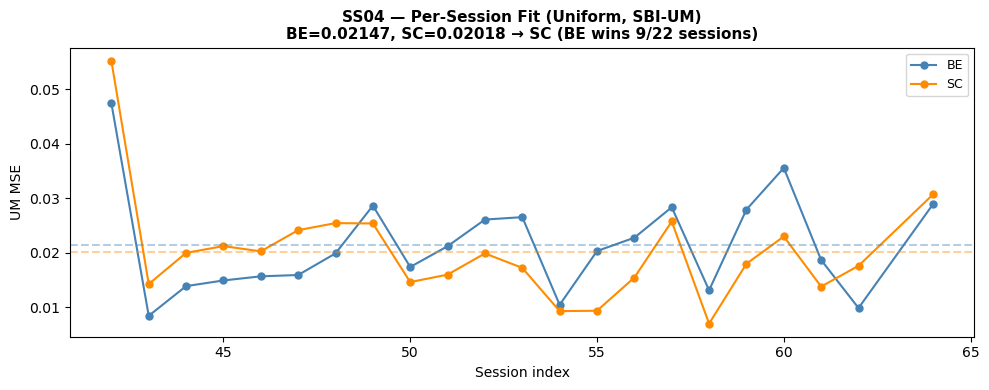

  SS04: params from GS-UM
    BE: sigma_percep=0.050, A_repulsion=0.000, eta_learning=0.100, eta_relax=0.400
    SC: sigma_percep=0.217, A_repulsion=0.333, gamma=0.953, sigma_update=0.700
  Simulating (22 sessions, 20 reps)...
  22 sessions done


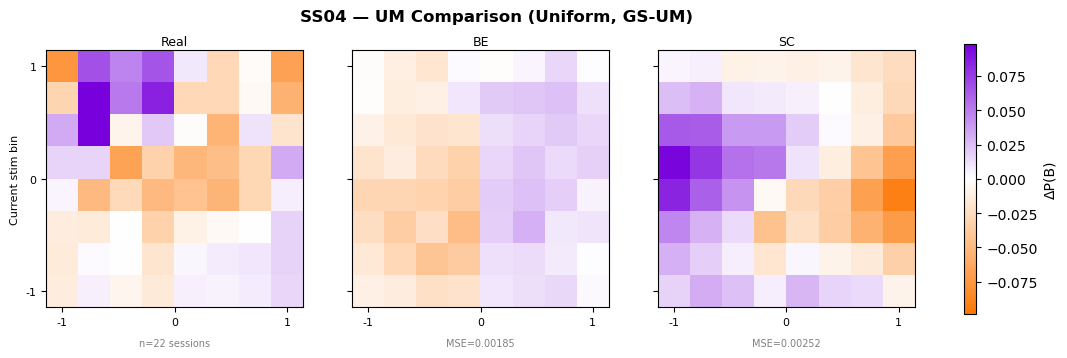

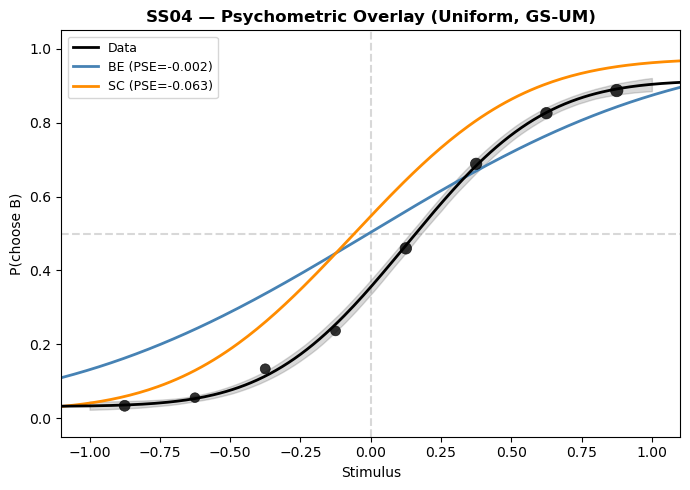


  Psychometric parameter comparison:
                        PSE     Slope (σ)     Lapse low    Lapse high
  Data                0.131         0.382         0.032         0.086
  BE                 -0.002         0.856         0.012         0.007
  SC                 -0.063         0.470         0.019         0.026


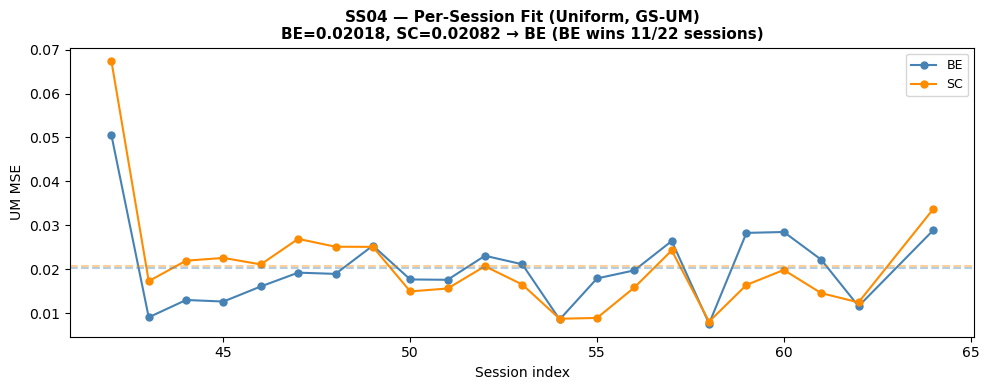

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

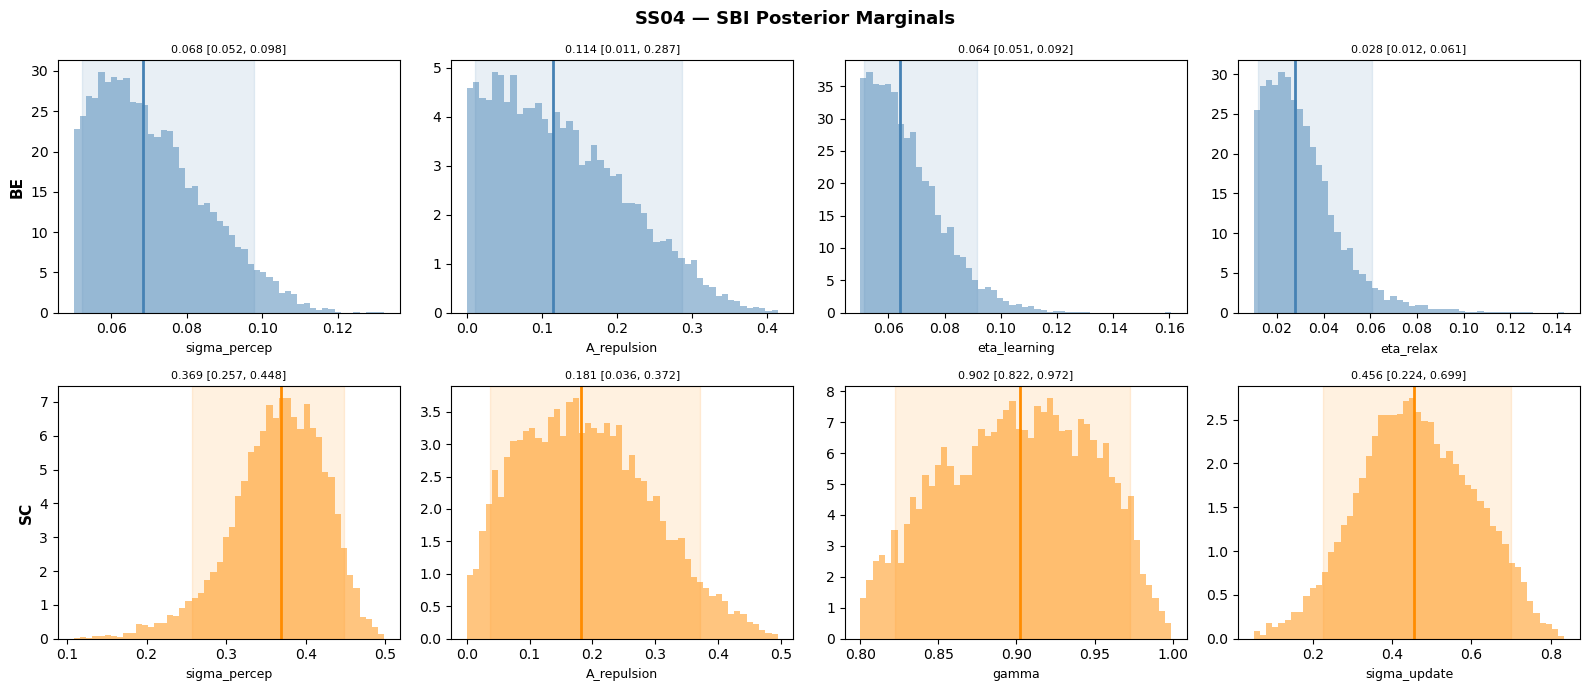

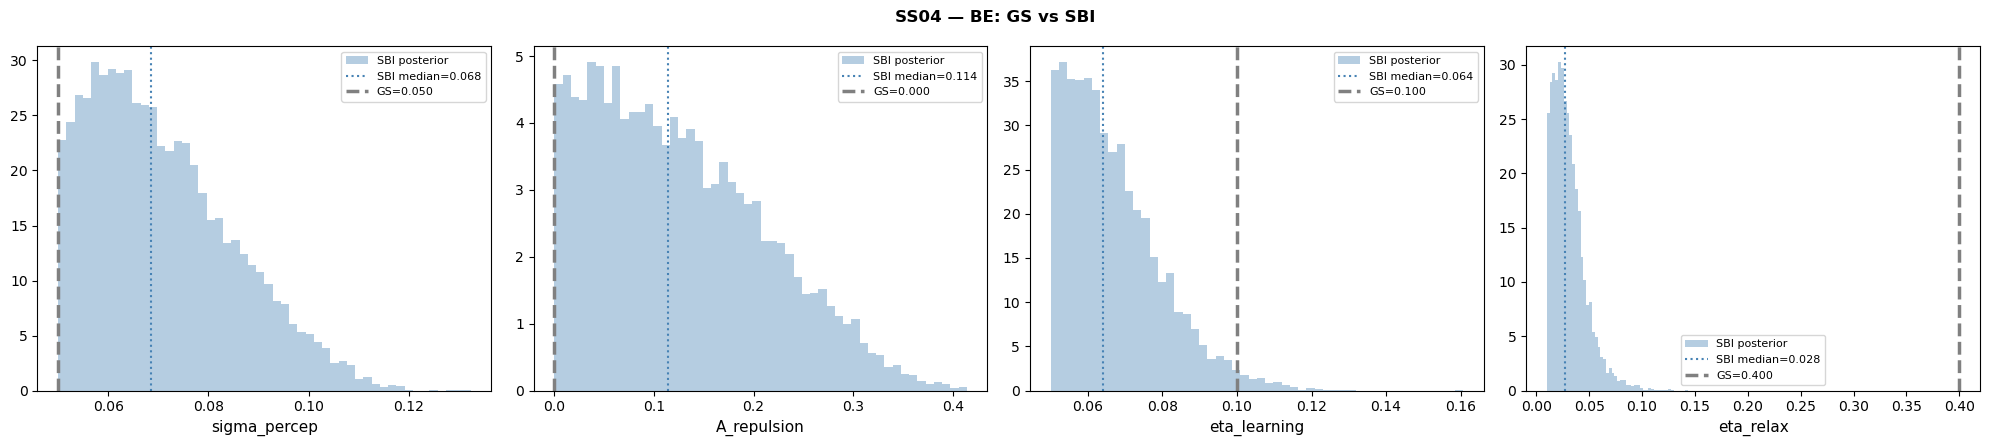

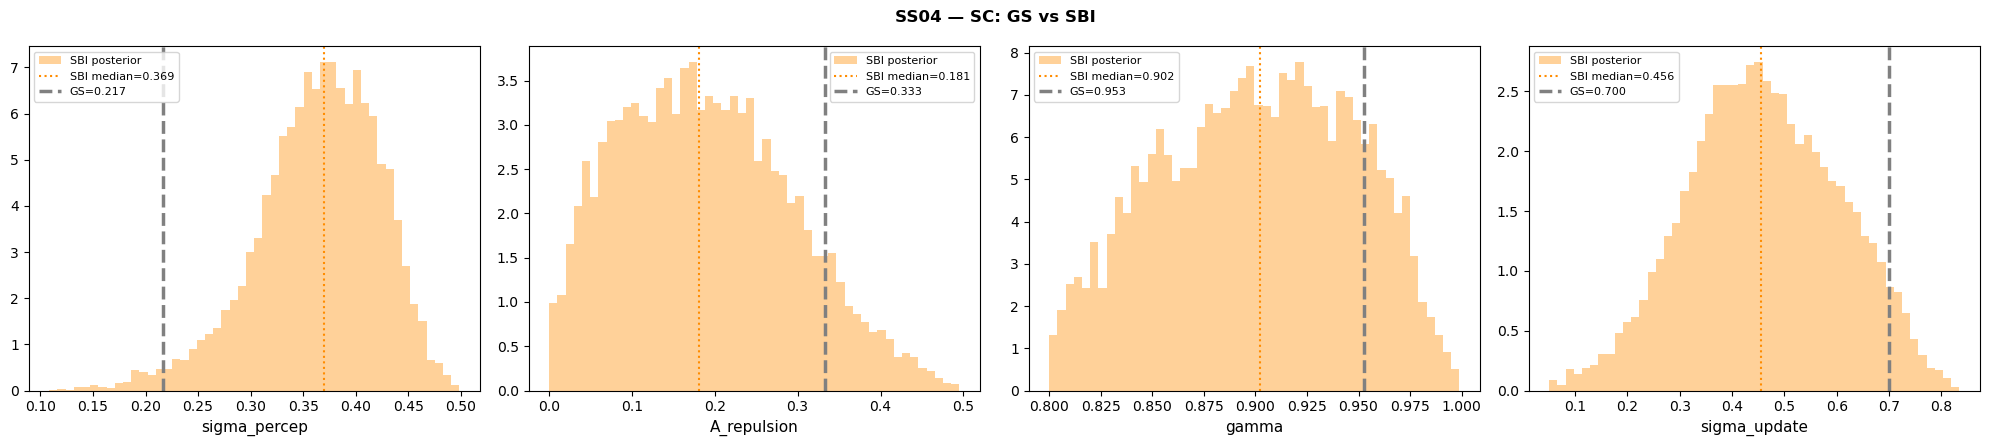

  BE PPC: all simulations failed
  SC PPC: all simulations failed


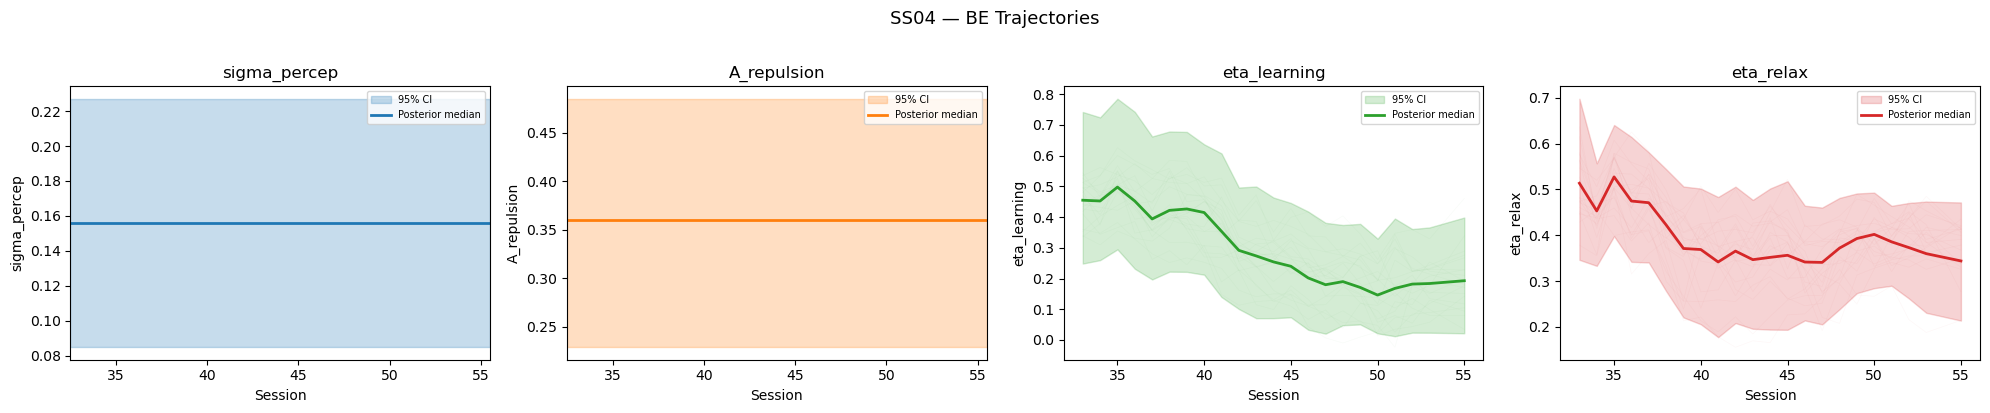

In [10]:
INSPECT_ID = 'SS04'  # ← change this

if INSPECT_ID not in experiment.animals:
    print(f'{INSPECT_ID} not found. Available:')
    for aid in sorted(experiment.animals.keys()):
        n = len(select_sessions(experiment.animals[aid], 'expert_uniform'))
        cons = assign_df.loc[assign_df['id'] == aid, 'Consensus'].values
        cons = cons[0] if len(cons) > 0 else '?'
        print(f'  {aid}: {n} expert sessions, consensus={cons}')
else:
    sessions = select_sessions(experiment.animals[INSPECT_ID], 'expert_uniform')
    if not sessions:
        print(f'{INSPECT_ID}: no expert sessions')
    else:
        print(f'Inspecting {INSPECT_ID} ({len(sessions)} expert sessions)')

        # Full analysis
        plot_animal_summary(INSPECT_ID, sessions, RESULTS_DIR)

        for ft in FIT_TARGETS:
            plot_cv_results(INSPECT_ID, RESULTS_DIR, fit_target=ft)

        plot_model_fits(INSPECT_ID, sessions, RESULTS_DIR, method='sbi')
        plot_model_fits(INSPECT_ID, sessions, RESULTS_DIR, method='gs')

        plot_sbi_diagnostics(INSPECT_ID, sessions, snpe, RESULTS_DIR)

        # Dynamic SBI if available
        if DYN_DIR.exists():
            for model in ['BE', 'SC']:
                p = DYN_DIR / f'{INSPECT_ID}_{model}.pkl'
                if not p.exists(): continue
                with open(p, 'rb') as f: d = pickle.load(f)
                fig = plot_parameter_trajectories(
                    d['trajectories'],
                    title=f'{INSPECT_ID} — {model} Trajectories',
                    show_samples=20)
                plt.show()